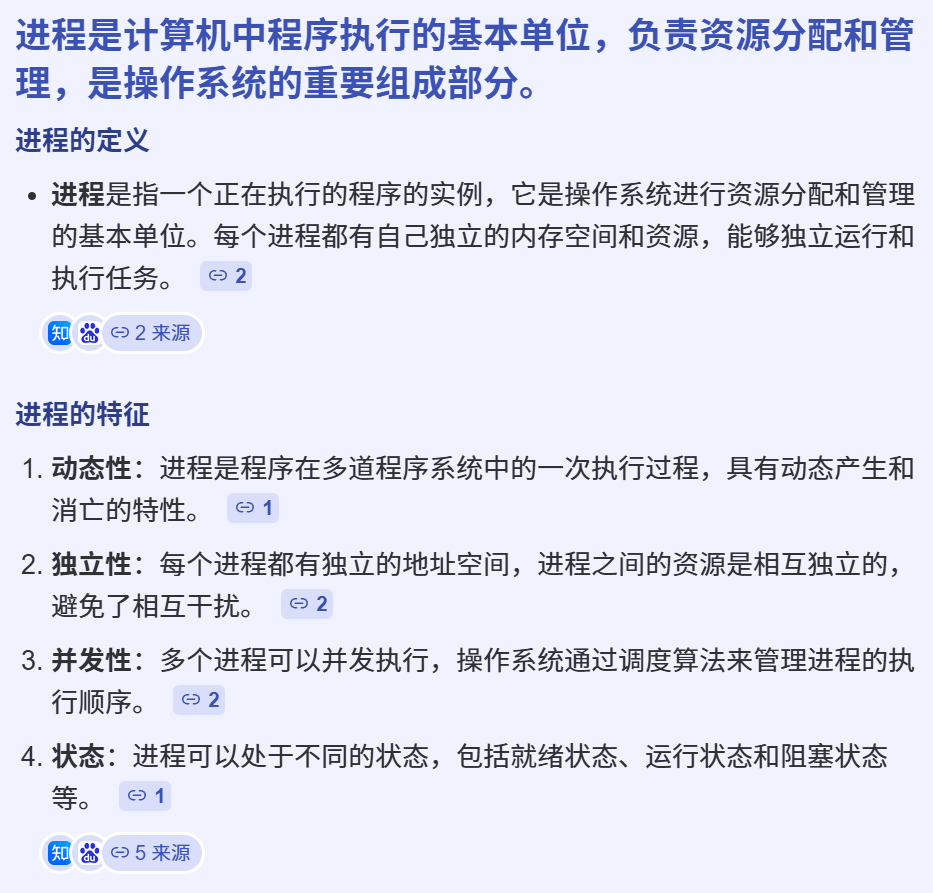

并发编程用于提高多核处理器的利用率，同时也可以提高程序的响应速度。

是分布式编程、网络编程的基础。


进程查看命令

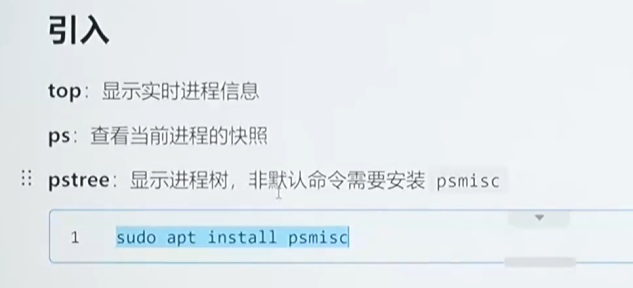

In [ ]:
进程：简而言之，进程是正在运行的程序的实例。
    执行程序时，内核会将程序代码载入虚拟内存，为程序分配内存空间和其他资源。
    建立内核记账（bookkeeping）数据结构，以跟踪进程的状态（进程ID，用户ID，组ID，以及终止状态等）和资源使用情况。

程序：
    源码形式
    二进制机器码

线程： 线程是进程中的一个执行流，是CPU调度和分派的基本单位。
    线程是进程的一个子集，线程共享进程的资源（内存空间、文件描述符等），但每个线程有自己的寄存器状态和堆栈。
    线程之间的切换开销比进程小得多，因为不需要切换内存空间和其他资源。


操作系统

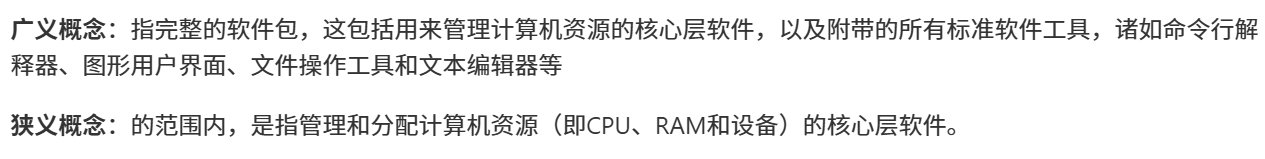

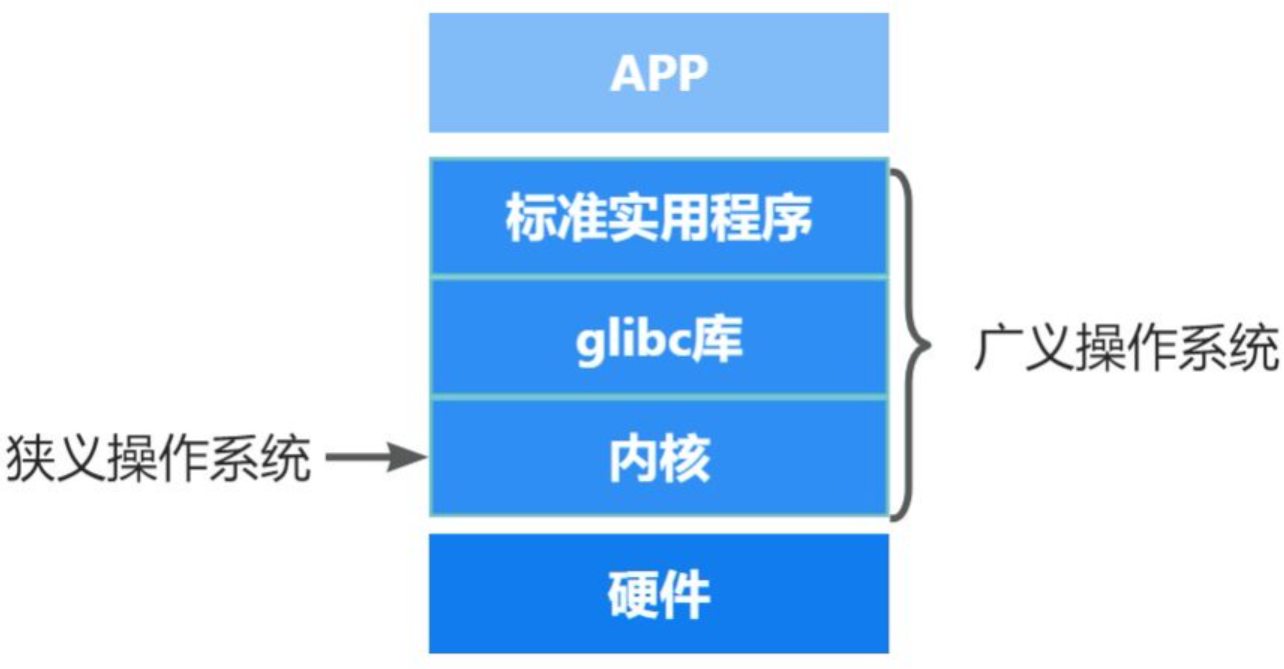

内核职责

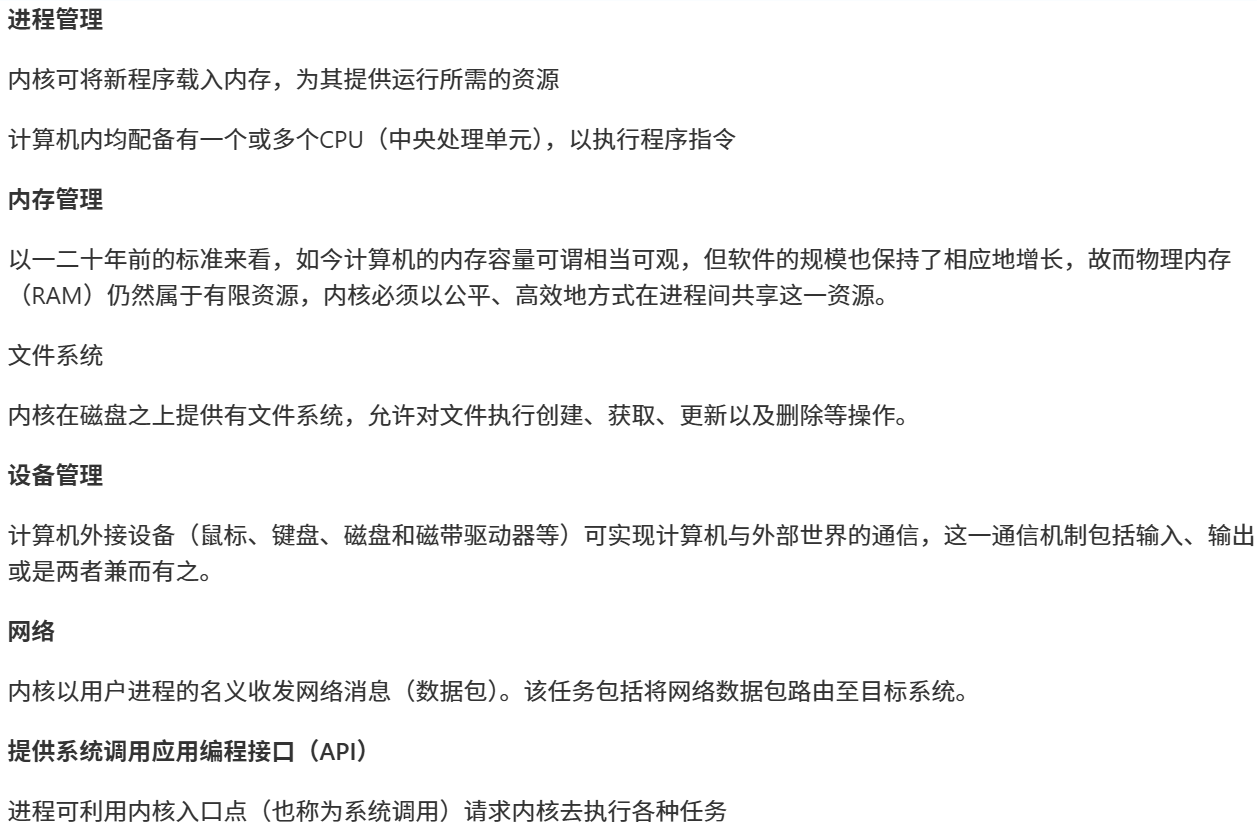

## 进程管理

### 进程的创建

In [ ]:
#include <stdio.h>
#include <unistd.h>
#include <sys/types.h>

pid_t pid = fork(); // 创建子进程

/* fork进入循环要小心，容易节外生枝、意外生成
*/


###### 子进程会继承父进程的进程身份、文件描述符、环境变量、内存空间、信号处理

一父多同级子进程

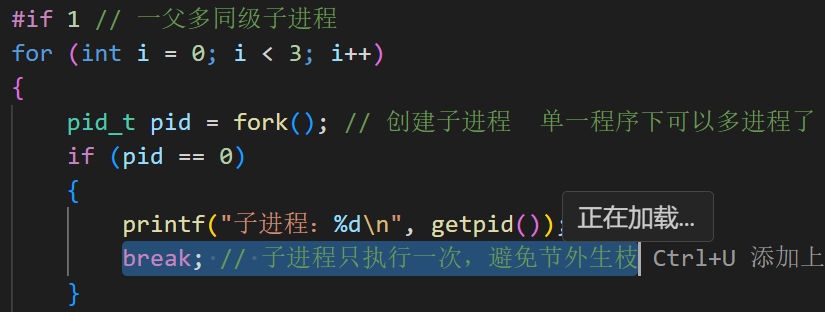

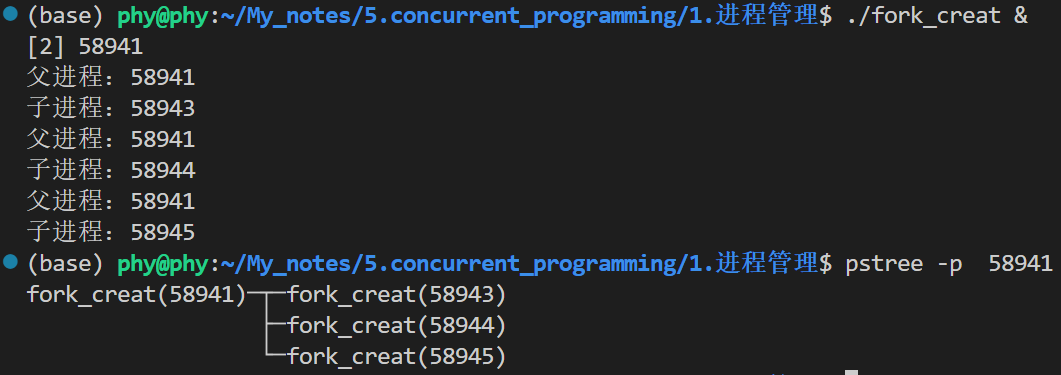

### 进程的终止

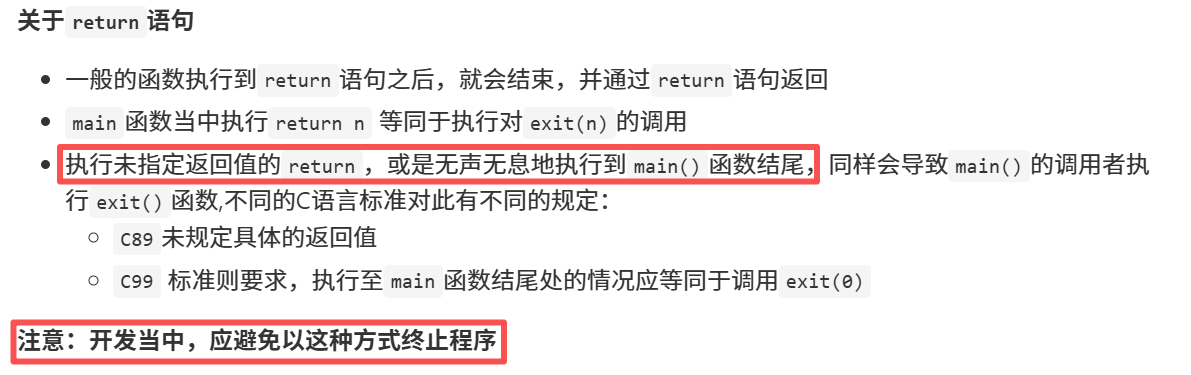

exit() 主要完成两件事：
- 刷新stdio缓冲区
- 终止进程

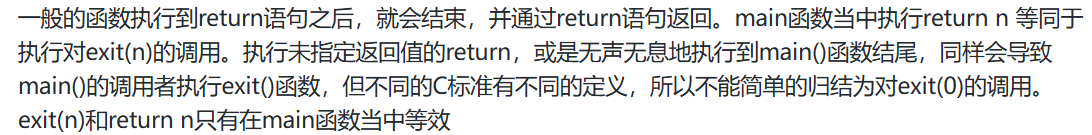

_exit() <系统调用的退出函数>


In [ ]:
#include <unistd.h>

void _exit(int status);


- 直接由系统内核终止进程，不刷新 stdio 缓冲区。
- 无返回，直接使进程终止

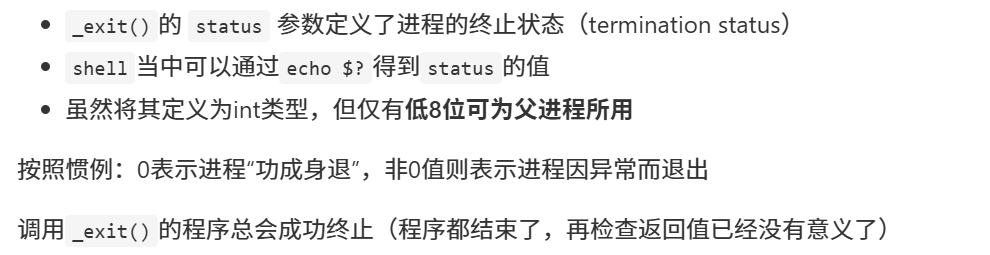

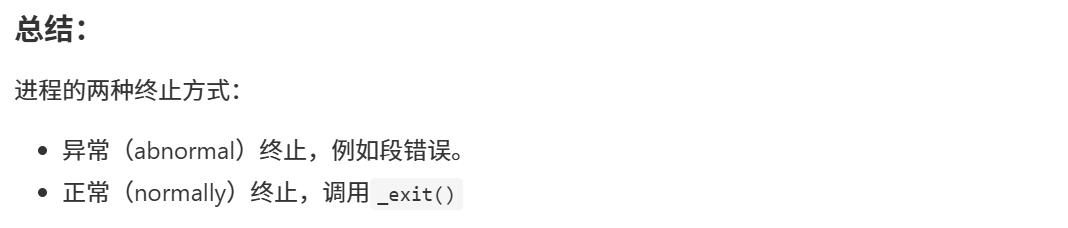

###### 父进程需要知道子进程的退出状态

### 进程状态

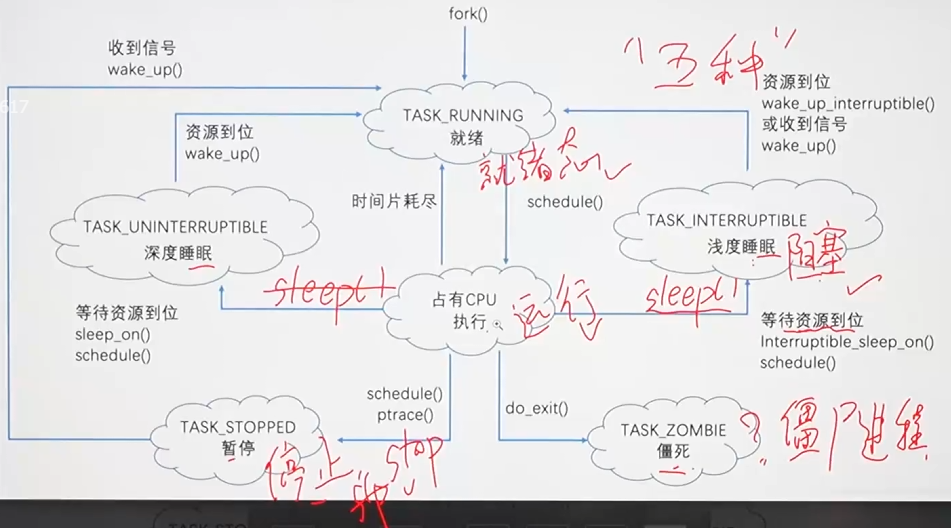

进程的几种状态

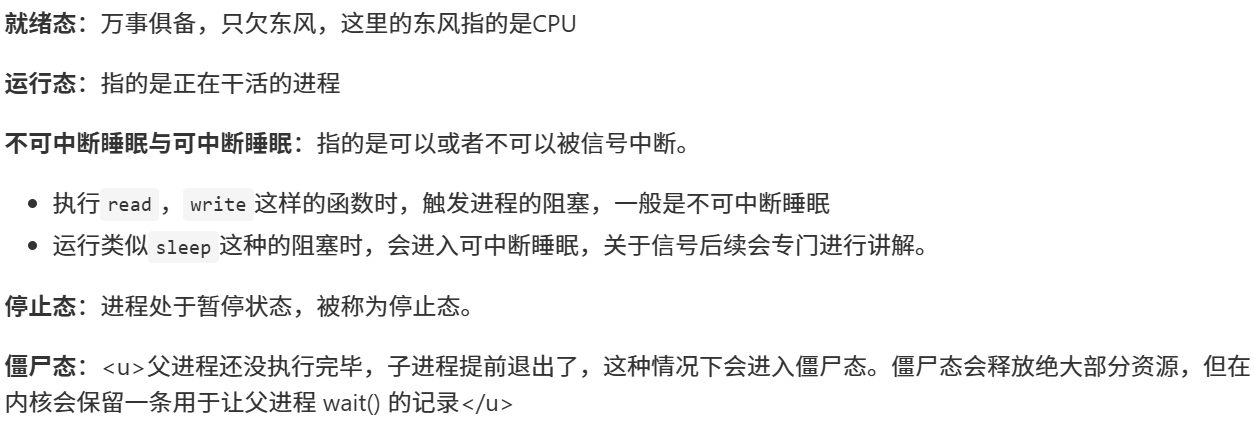

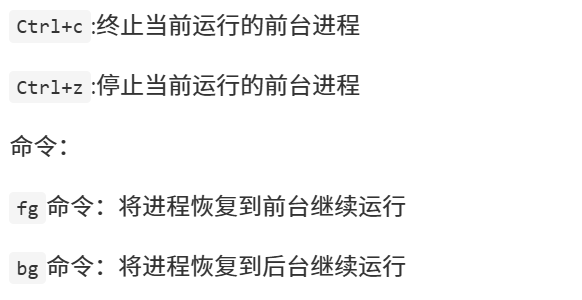

###### 后台进程僵死，拉到前台结束

#### 僵尸进程

In [ ]:
子进程已经终止，但父进程没有及时调用 wait() 或 waitpid() 来回收子进程的退出状态。

- 父进程未处理子进程退
    子进程执行完毕退出后，内核会保留其退出状态信息
    父进程必须调用 wait() 系列函数来获取这些信息
    如果父进程不处理，子进程就会变成僵尸进程

- 父进程运行时间过长
    父进程忙于其他任务，没有及时检查子进程状态
    子进程先于父进程结束，但父进程没有回收

- 编程错误
    忘记在父进程中调用 wait() 或 waitpid()
    信号处理不当，忽略了 SIGCHLD 信号


#### wait() 函数

In [ ]:
#include <sys/types.h>
#include <sys/wait.h>

pid_t wait(int *wstatus);


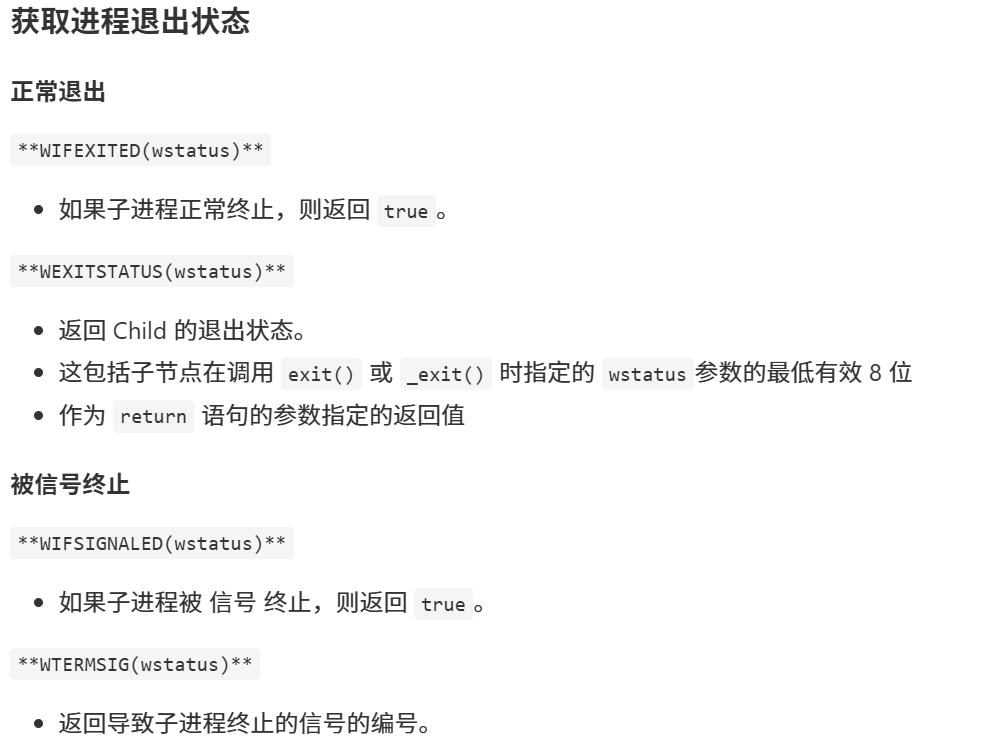

#### wait() 函数相关问题

In [ ]:
// 1.如果只有一个子进程，而出现两次wait()函数会怎样？

     /*第二次调用 wait() 会阻塞或立即返回错误*/
     // wait: No child processes
     
// 2.如何等待全部子进程的结束？
#include <stdio.h>
#include <sys/types.h>
#include <unistd.h>
#include <stdlib.h>
#include <sys/wait.h>

int main(int argc, const char *argv[])
{
	int time = 4; //进程数量，可以随意调整
	pid_t pid = 1;
	while(time-- && pid > 0) {
		switch( (pid = fork()) ){
		case -1:
			perror("fork");
			exit(EXIT_FAILURE);
			break;
		case 0:
			printf("做点别的事情\n");
			sleep(1);
			exit(EXIT_FAILURE);
			break;
		default:
		}
	}
	//....
	while( wait(NULL) > 0) { //简单循环等待（阻塞模式）
		perror("wait");
	}
	return 0;
}


#### 加强版“wait”——waitpid()

In [ ]:
#include <sys/types.h>
#include <sys/wait.h>

pid_t waitpid(pid_t pid, int *wstatus, int options);


- pid:进程号，-1表示等待任意子进程
- wstatus:指向int类型的指针，用于存储子进程的退出状态
- options:
    - 0 阻塞等待
    - WNOHANG 非阻塞等待 如果没有子进程退出立即返回0
    - WUNTRACED 等待停止的子进程 返回停止的子进程状态信息
    - WCONTINUED 等待继续执行的子进程 返回继续执行的子进程状态信息

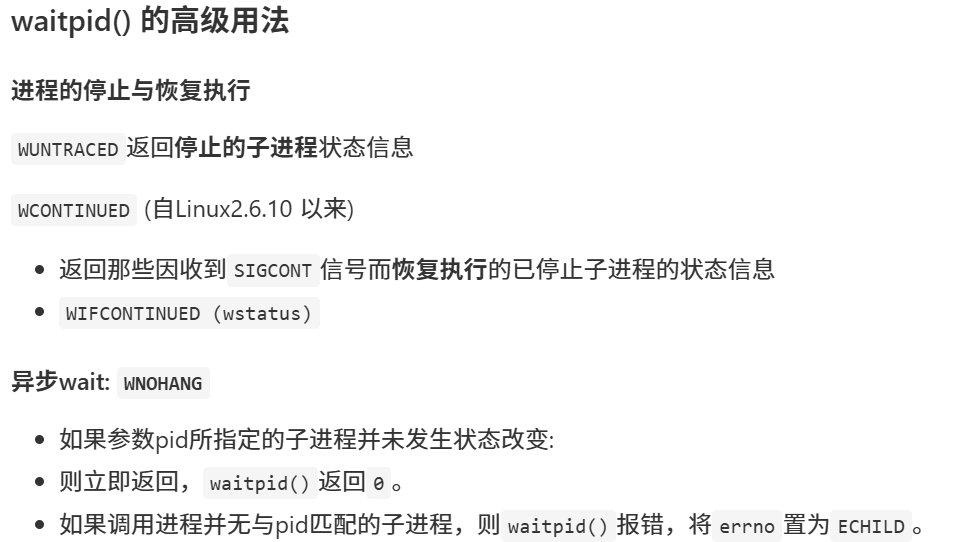

### system()和exec函数族

In [ ]:
#include <stdlib.h>

int system(const char *command); // 执行shell命令


In [ ]:
// 运行任意shell命令
#include <stdlib.h>
#include <stdio.h>

int main(int argc, char *argv[])
{   
    char buf[1024] = {};
    while(1){
        printf("输入命令-->");
        // scanf("%s", buf);  scanf会忽略前导空格，并在遇到空格时停止读取。
                              // 就只能读取一个命令
        fgets(buf, sizeof(buf), stdin); // 按行从标准输入读取命令
        system(buf);
    }
    
    return 0;
}


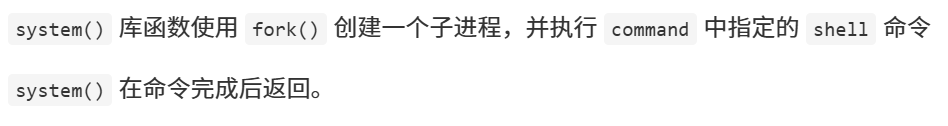

###### system函数默认调用 /bin/sh，而不是直接调用 bash
- system() 的内部实现大致如下：
    - 1. fork() 创建子进程
    - 2. 在子进程中调用 exec 执行 "/bin/sh -c command"
    - 3. 父进程等待子进程结束


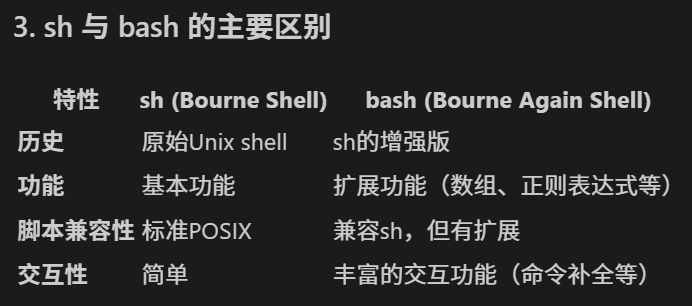

#### system()的安全风险

In [ ]:
system()在运行时可以运行rm命令删除任意系统文件，被命令注入攻击。
一般执行文件使用exec函数，而不是system()函数。


#### exec函数族

In [ ]:
#include <unistd.h>

int execl(const char *pathname, const char *arg, .../* (char  *) NULL */);
int execlp(const char *file, const char *arg, .../* (char  *) NULL */);
int execle(const char *pathname, const char *arg, .../*, (char *) NULL, char *const envp[] */);
int execv(const char *pathname, char *const argv[]);
int execvp(const char *file, char *const argv[]);
int execvpe(const char *file, char *const argv[], char *const envp[]);

// exec函数族返回值：
// 成功：无返回值，直接执行新程序
// 失败：返回-1，设置errno


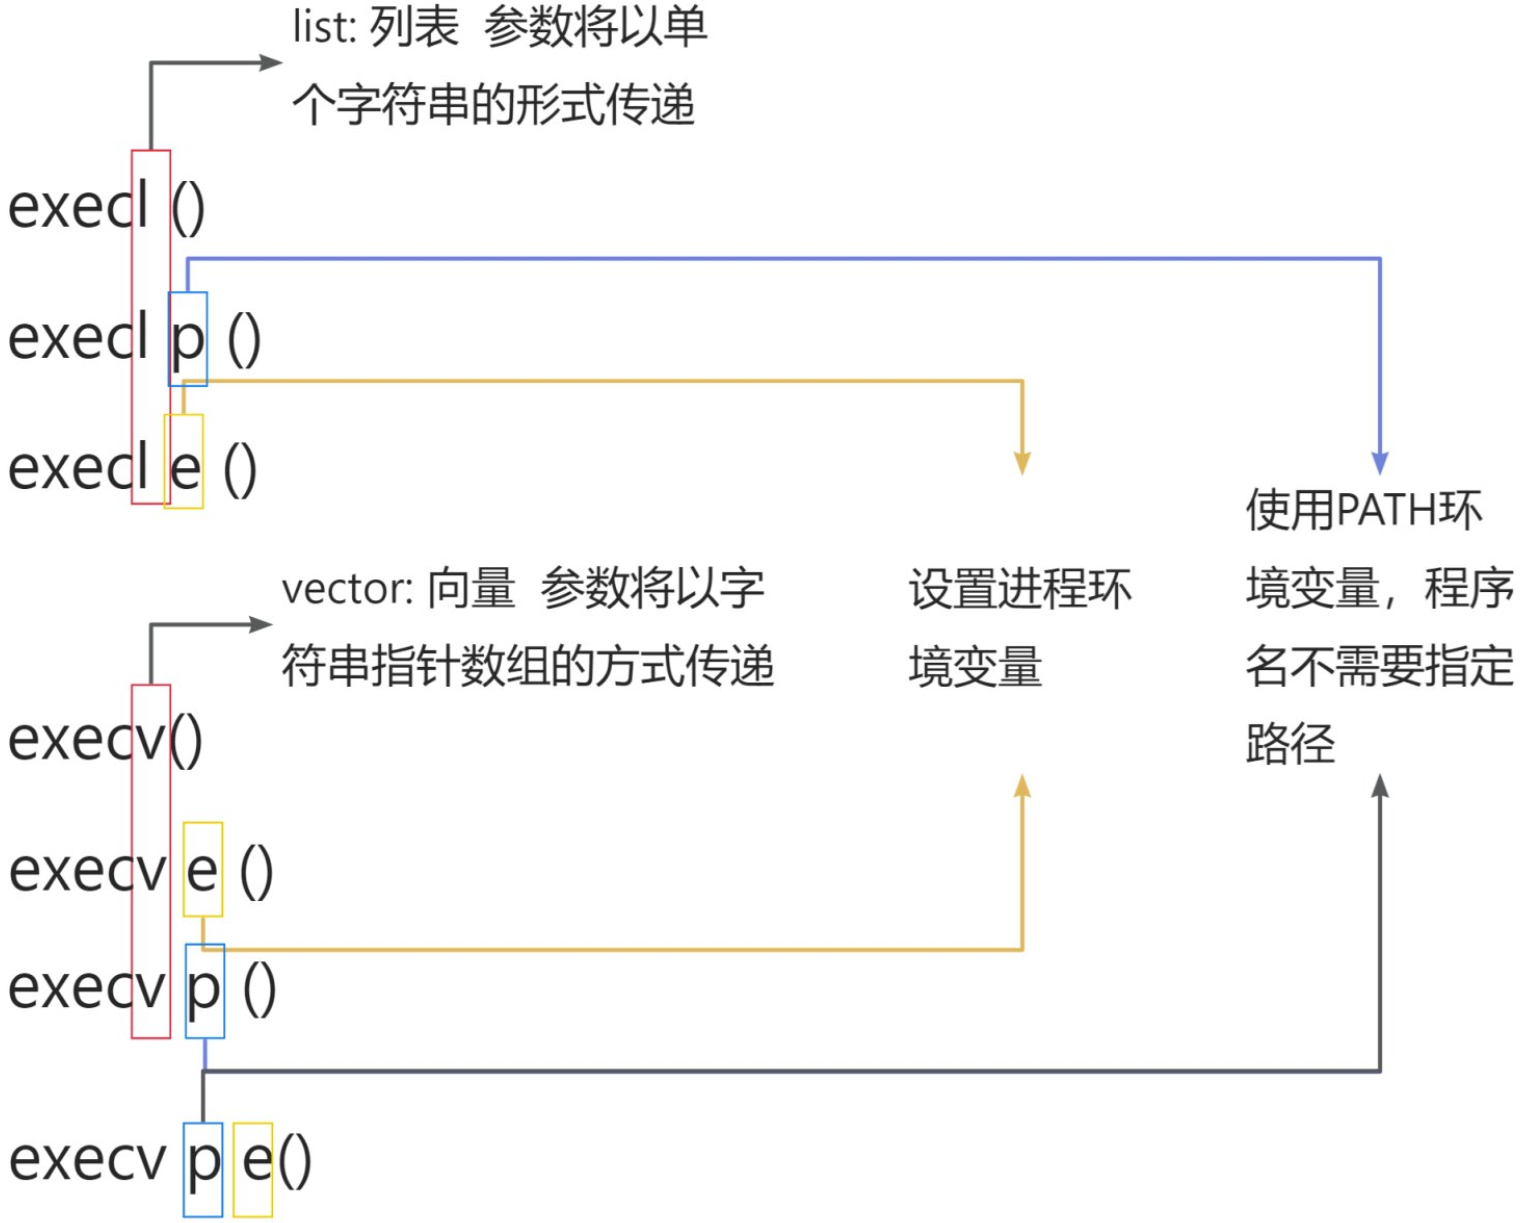

##### execl()与execv()示例

In [ ]:
#include <unistd.h>
#include <stdio.h>

int main() {
    execl("/bin/pwd", "pwd", NULL);
    perror("execve");
    return 1;
}

int main() {
	char *args[] = {"ls", "-l", NULL};
    execv("/bin/ls", args);
    perror("execve");
    return 1;
}


##### execlp()与execvp()示例

In [ ]:
#include <unistd.h>
#include <stdio.h>

int main() {
    execlp("ls", "ls", "-l", "-a", NULL);
    perror("execve");
    return 1;
}

int main() {
	char *args[] = {"ls", "-l", NULL};
    execvp("ls", args);
    perror("execve");
    return 1;
}


##### 继承进程之前的环境变量

In [ ]:
#include <stdio.h>
#include <stdlib.h>
#include <unistd.h>

int main() {
    // 打印环境变量 USER 的初始值
    printf("Initial value of USER: %s\n", getenv("USER"));

    // 设置环境变量 USER 为 "britta"
    if (putenv("USER=britta") != 0) {
        perror("putenv");
        exit(EXIT_FAILURE);
    }

    // 使用 execl 调用 /usr/bin/printenv 命令，打印环境变量 USER 和 SHELL
    execl("/usr/bin/printenv", "printenv", "USER", "SHELL", (char *)NULL);

    // 如果 execl 调用失败，输出错误信息
    perror("execvpe");

    // 退出程序，返回失败状态
    exit(EXIT_FAILURE);
}


### 守护进程

#### 孤儿进程 （是个问题，无人监视管理）
- 孤儿进程是指父进程先于子进程结束，而子进程还在运行的进程。
- 孤儿进程会被init进程（进程号为1）收养，init进程会负责管理孤儿进程的生命周期。

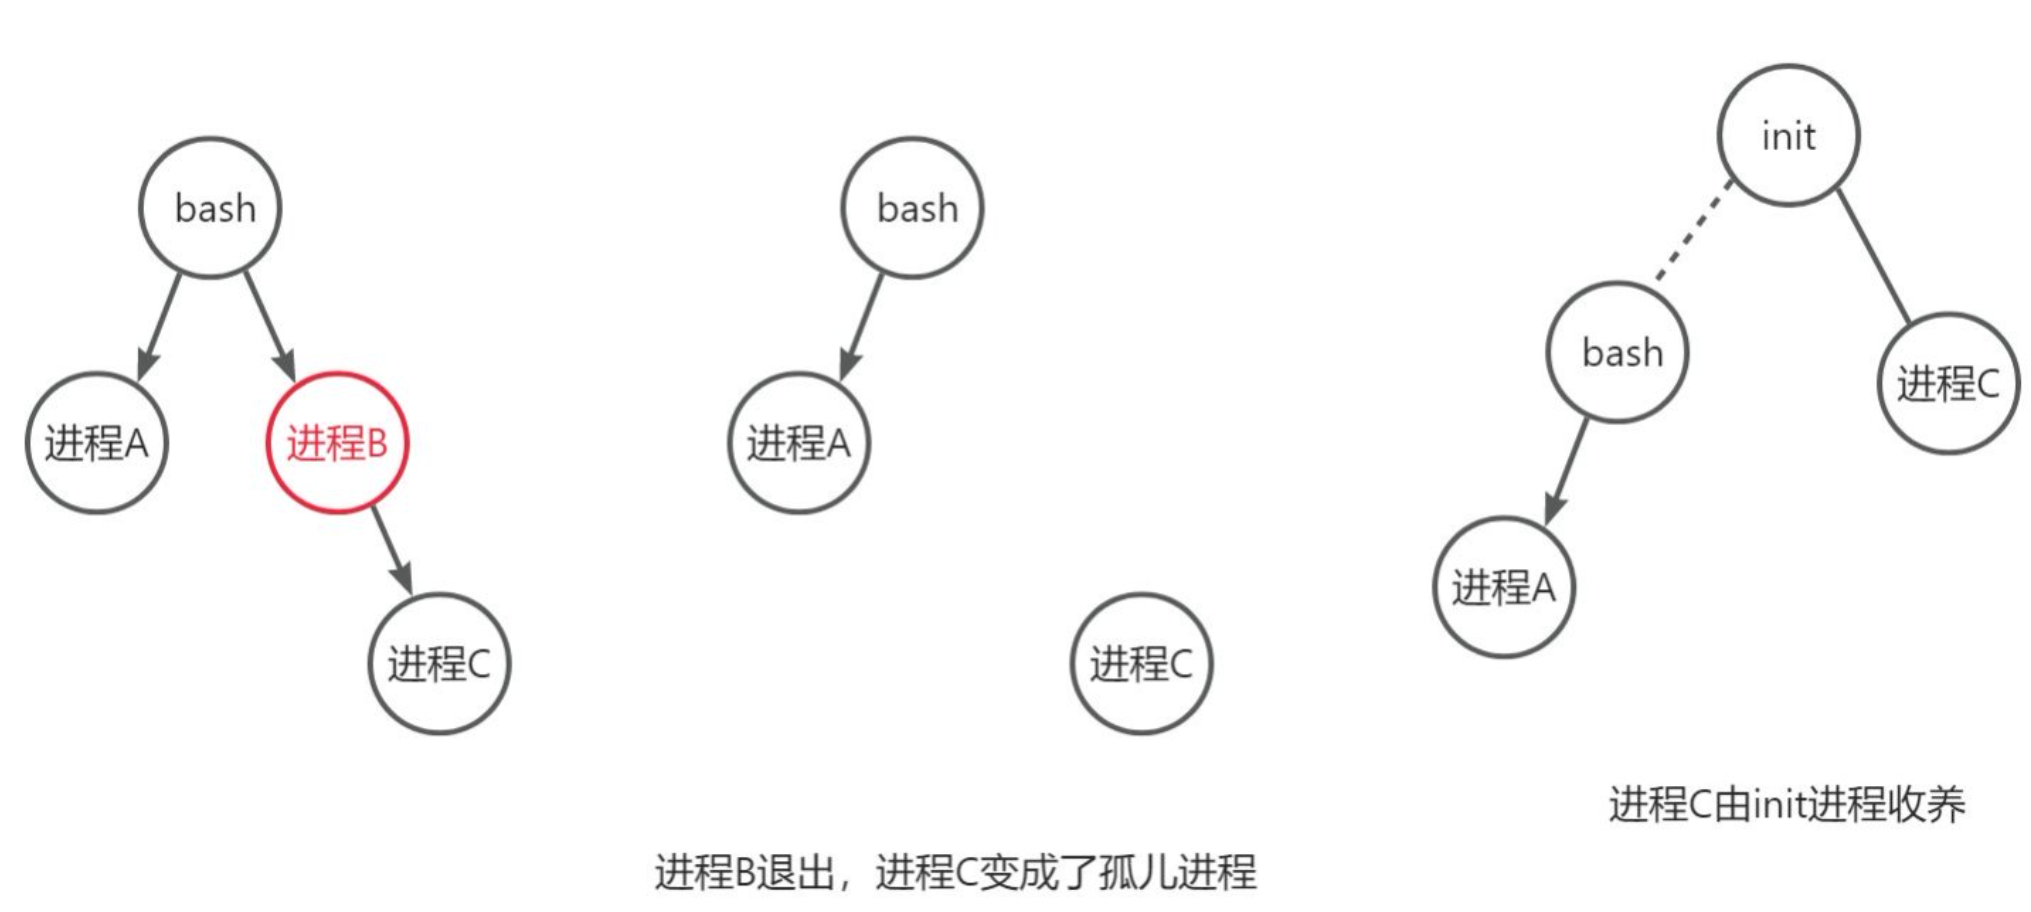

###### 需要一个进程作为它的父进程继续管理它。

##### 孤儿进程与僵尸进程

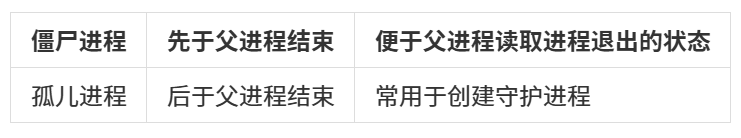

##### 孤儿进程与守护进程

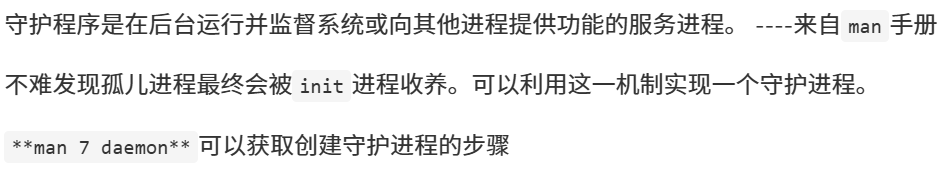

#### 实现守护进程

##### 一、脱离终端

In [ ]:
setsid();

if(fork() > 0) exit(0); //进程组首进程不能成为会话首进程，所以这一步很关键
setsid(); //成立一个会话


##### 二、关闭stdio流

In [ ]:
// 在程序开始时，标准输入流、标准输出流、标准错误流自己就被打开了

close(0); // 关闭标准输入流
close(1); // 关闭标准输出流
close(2); // 关闭标准错误流

// 或者

close(STDIN_FILENO);
close(STDOUT_FILENO);
close(STDERR_FILENO);


##### 三、设置umask

###### 文件权限掩码，同时它也是进程的属性

In [ ]:
#include <sys/types.h>
#include <sys/stat.h>

mode_t umask(mode_t mask);


###### 对umask()的调用总会成功，并返回进程的前一umask

In [ ]:
#include <stdio.h>
#include <sys/stat.h>
#include <sys/types.h>

int main(int argc, const char *argv[])
{
	umask(0222);  //设置本进程的umask
    
    //由于后面不再做任何事所以这里省略了错误判断
	mkdir("/home/linux/process/tmp_mkdir", 0777); 
	perror("mkdir");//提示目录文件是否创建成功
	return 0;
}


##### 四、设置工作路径

In [ ]:
    if( -1 == chdir("/") ) {
		perror("chdir");
		exit(EXIT_FAILURE);
	}


### 信号

- 一种通信机制
    - 信号是事件发生时对进程的`通知机制`
    - 相较硬件中断，信号是`软件中断`（借鉴了硬件中断的机制）
    - 信号与硬件中断相似之处是它打断了程序执行的正常流程
- 通常源于内核
    - 硬件异常
        - 包括执行一条异常机器语言指令（除0、引用无法访问内存区域）
    - 终端特殊字符
        - 中断字符（如Ctrl+C）
        - 退出字符（如Ctrl+D）
        - 暂停字符（如Ctrl+Z）
    - 软件事件
        - 调整了终端窗口大小
        - 定时器到期
        - 子进程终止

- 是一个整数
    - 每个信号都有一个唯一的（小）整数编号，从1开始顺序展开
    - <signal.h>以SIGxxxx形式的符号名对每个信号（整数）进行了定义
    - Linux中标准信号编号为1-31


#### 信号响应过程

##### 信号的等待(pending)状态

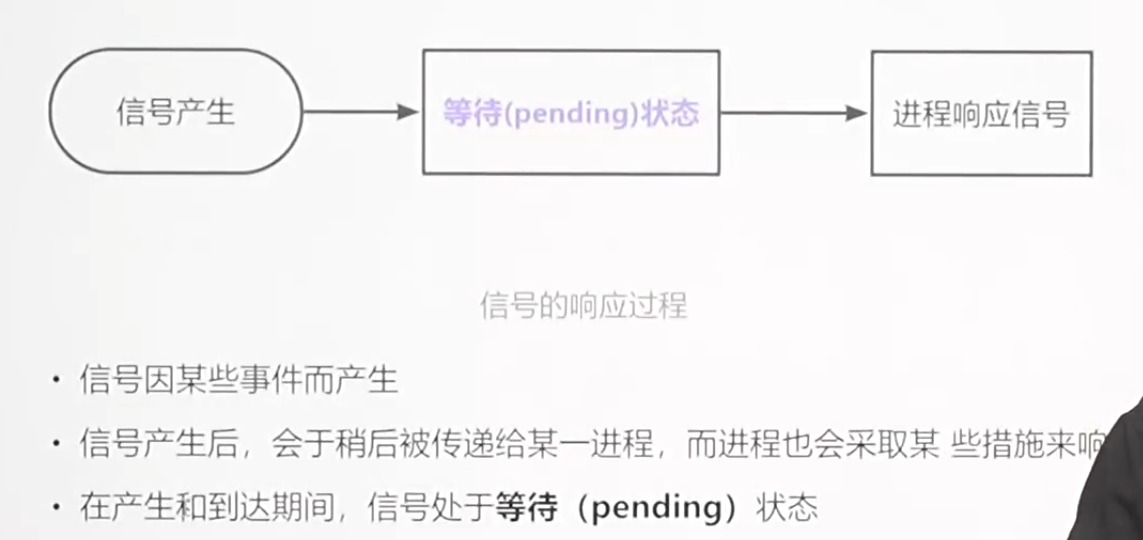

##### 信号的处置(disposition)

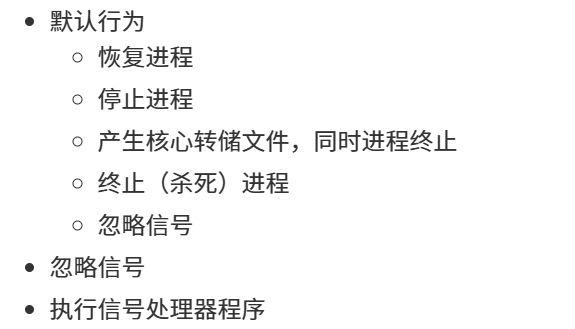

##### 关于信号处理器程序

信号处理器程序是<u>由程序员编写的函数</u>，用于为响应传递来的信号而执行适当任务

通知内核应当去调用某一处理器程序的行为，通常称之为安装或者建立信号处理器程序

调用信号处理器程序以响应传递来的信号，则称之为信号已处理（handled），或者已捕获（caught）

#### 信号类型和默认行为

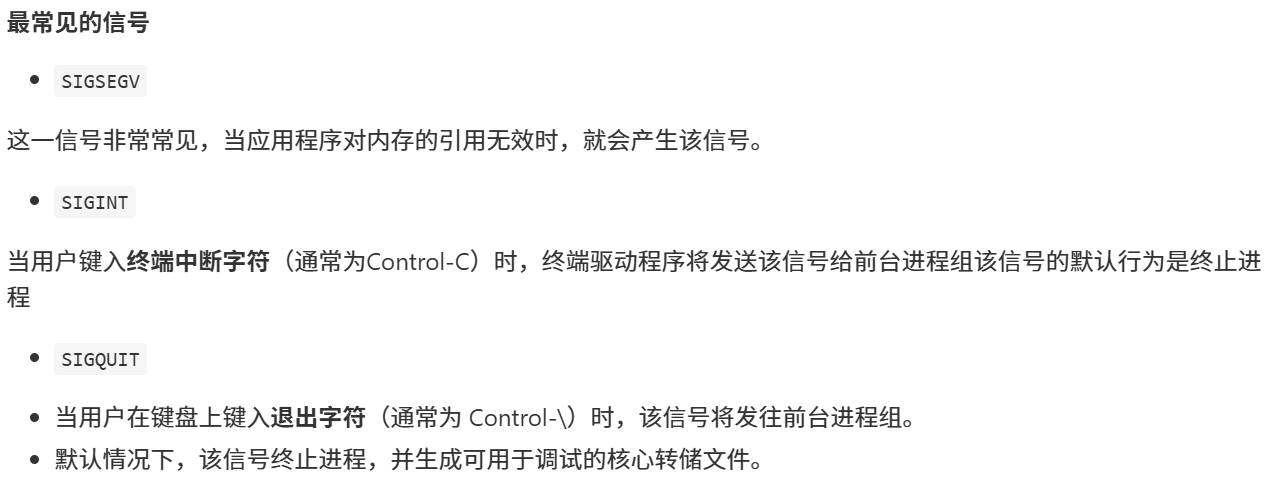

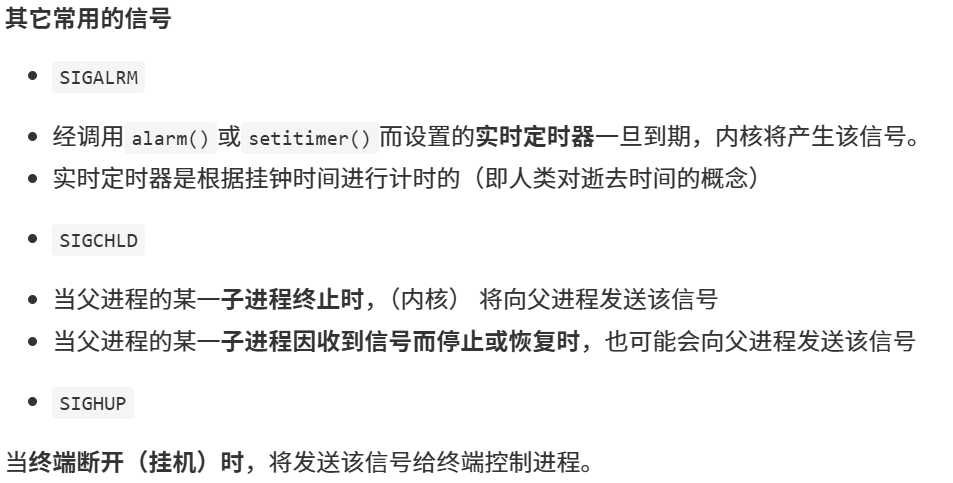

###### 下为更多信号类型和默认行为

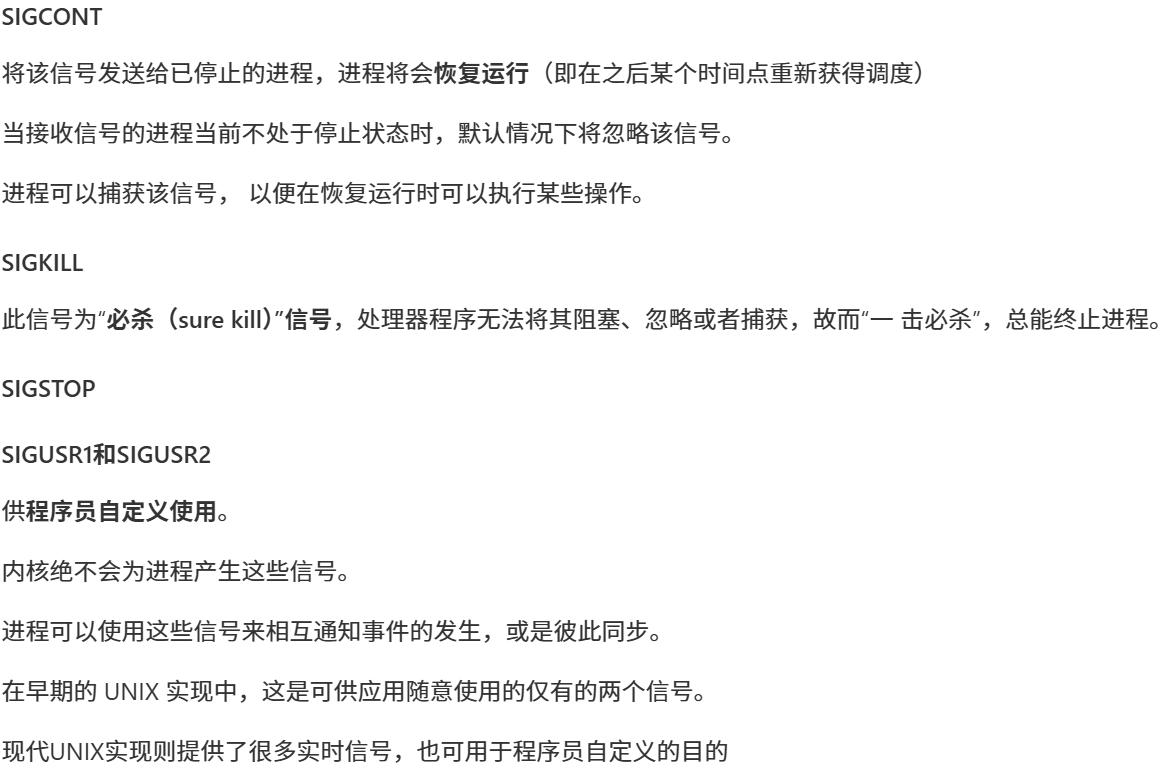

#### 信号集

是种数据类型。多个信号可使用一个称之为信号集的数据结构来表示，其系统数据类型为`sigset_t`.

信号集的使用
- 初始化
    ````c
    #include <signal.h>
    int sigemptyset(sigset_t *set); //信号集初始化为空
    int sigfillset(sigset_t *set);  //信号集初始化为包含所有信号
    ````
- 添加或者移除单个信号
    ````c
    #include <signal.h>
    int sigaddset(sigset_t *set, int signum);
    int sigdelset(sigset_t *set, int signum);
    ````
- 测试信号是否是信号集的成员
    ````c
    #include <signal.h>
    int sigismember(const sigset_t *set, int signum);
    ````

#### 信号掩码

##### sigprocmask()添加信号掩码
````c
#include <signal.h>
/* Prototype for the glibc wrapper function */
int sigprocmask(int how, const sigset_t *set, sigset_t *oldset);
````

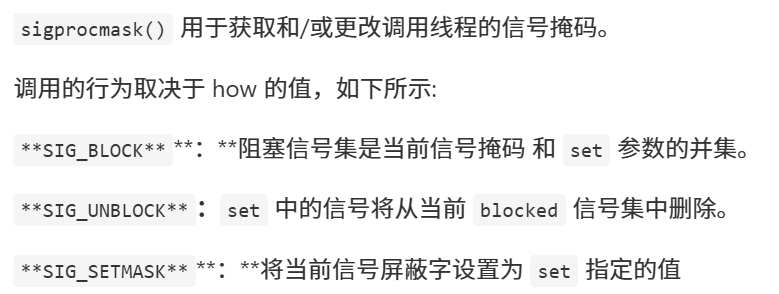

In [ ]:
#include <stdio.h>
#include <unistd.h>
#include <stdlib.h>
#include <signal.h>

int main(int argc, const char *argv[])
{
	sigset_t blockSet, prevMask;
	sigemptyset(&blockSet);
	sigaddset(&blockSet, SIGINT);
	if ( sigprocmask(SIG_BLOCK, &blockSet, &prevMask) == -1) {
		perror("sigprocmask");
		exit(0);
	}
	sleep(5);
	return 0;
}


#### sigaction函数(—信号处置)

````c
#include <signal.h>
// 检查或更改信号处置
int sigaction(int signum, const struct sigaction *act, struct sigaction *oldact);
````
参数：
- signum：要操作（检查或更改）的信号编号

- act：指向 sigaction 结构体的指针，用于指定新的信号处置。若act非NULL，则act安装新的信号处置；若act为NULL，则仅检查信号处置而不更改。

- oldact：指向 sigaction 结构体的指针，用于返回旧的信号处置。非NULL时，sigaction将前一个信号处理器程序保存在oldact指向的结构体中。

````c
// sigaction结构体
struct sigaction {
    void (*sa_handler)(int);                        //指向信号处理器函数的指针
    void (*sa_sigaction)(int, siginfo_t *, void *); //处理标准信号时一般不使用
    sigset_t sa_mask;                               //信号掩码
    int sa_flags;                                   //选项
    void (*sa_restorer)(void);                      //仅供glibc库内部使用
};
````

sa_handler:
- 信号处理程序函数指针
- 如果设置为`SIG_DFL`修改信号的处置方式为默认处置方式
- 如果设置为`SIG_IGN`修改信号的处置方式为忽略此信号

sa_mask：
- 指定在信号处理程序执行期间应阻止的信号掩码

sa_flags：(sa_flags 指定一组修改信号行为的标志。它由以下零个或多个的按位 OR 组成)
- 默认情况下设置为0

ps:`在某些架构中，可能是以联合体的形式实现的，所以不要同时设置给sa_handler和sa_sigaction`

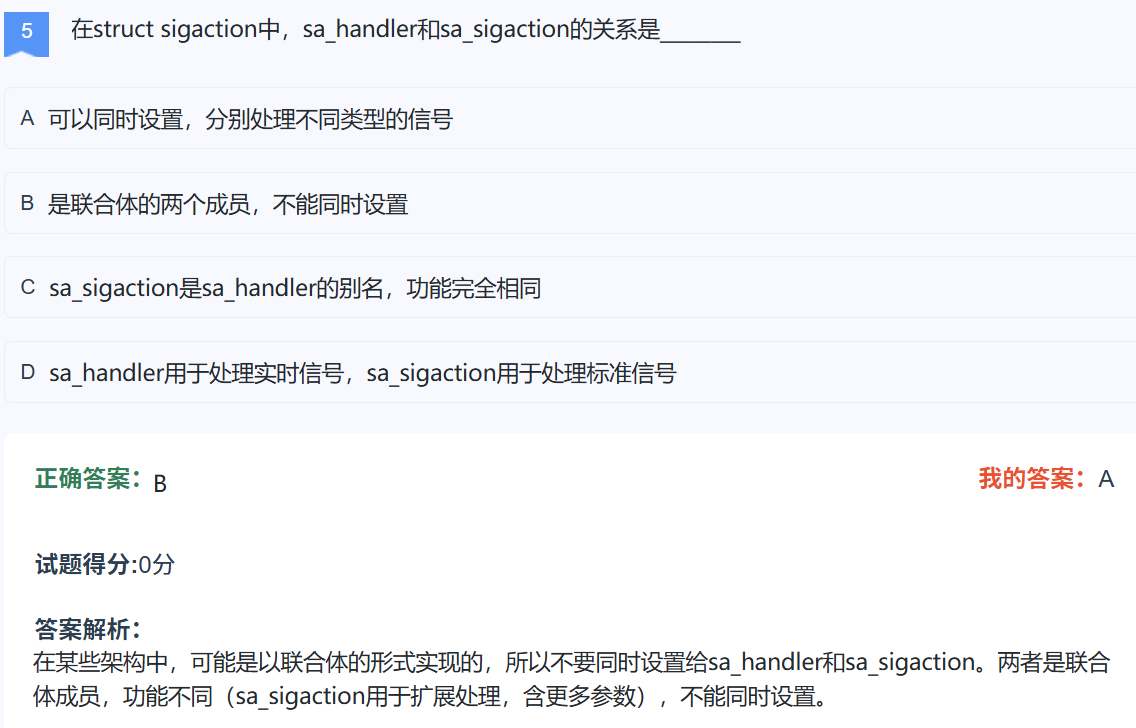

#### signal函数(—信号处置)  简单但不安全

````c
#include <signal.h>

typedef void (*sighandler_t)(int);
sighandler_t signal(int signum, sighandler_t handler);
````
参数：
- signum：需要处理信号类型
- handler：信号处理方式（函数指针）
    - SIG_DFL：默认处理方式（如SIGINT 默认终止程序）
    - SIG_IGN：忽略信号（如忽略SIGIPE 可避免程序因为管道破裂而终止）
    - 自定义处理函数（函数指针）：指向用户自定义信号处理函数的指针，原型是void handler(int signum)，其中signum是触发的信号类型。
        


In [ ]:
// signal示例

#include <stdio.h>
#include <stdlib.h>
#include <signal.h>
#include <unistd.h>

void timeout_handler(int signum) {
    fprintf(stderr, "触发定时器\n");
    alarm(2); // 2 秒后触发 SIGALRM  处理alarm定时器信号
}

int main() {
    signal(SIGALRM, timeout_handler);
    alarm(2); // 2 秒后触发 SIGALRM
	while(1) sleep(1);
    return 0;
}


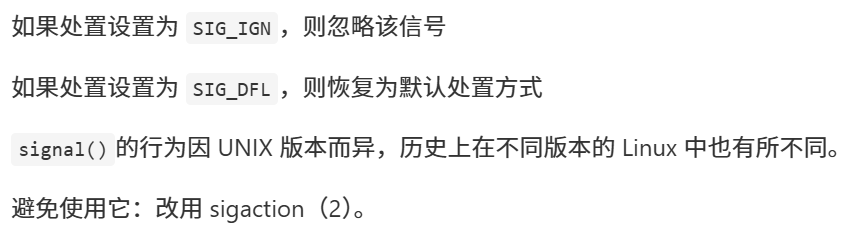

###### signal不统一，不安全

## 线程控制

---

进程内存分布

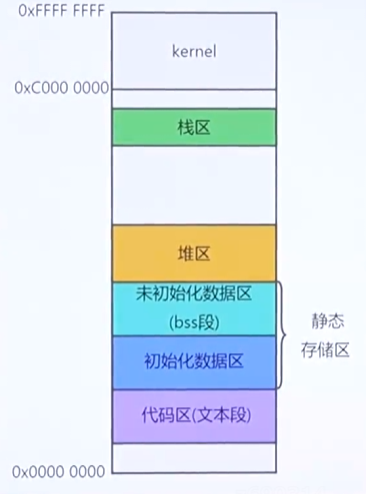

系统调用触发中断后才能进入内核空间

In [ ]:
stack：自动变量
heap：动态分配的内存
静态存储区（静态变量）：
    bss：未初始化数据区
    data：初始化数据区
text：文本段（代码段）


***

多线程程序内存分布

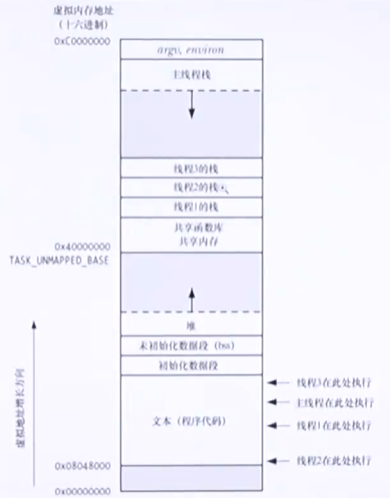

---

### 线程定义
- 线程是进程当中的执行流。

- 课程之前的进程，可以被认为是只有单个线程的进程。

- 同一程序中的所有线程均会独立执行相同程序， 且共享同一份全局内存区域，其中包括初始化数据段（initialized data）、未初始化数据段 （uninitialized data），以及堆内存段（heap segment）。

- `同一进程`中的`多个线程`可以`并发`执行。

- 在`多处理器`环境下，`多个线程`可以同时`并行`执行。

- 如果一线程因等待I/O操作而遭阻塞，那么其他线程依然可以继续运行。

#### 并发和并行
- 并发（Concurrent）：多个任务在`同一时间点`上`交替执行`。
    - 多个线程可以异步执行，所谓异步是指相互不受干扰
- 并行（Parallel）：多个任务在`同一时间点`上`同时执行`。
    - 硬件实现同进执行，是真正的同时执行，这需要多核CPU，或单核多线程CPU，又或者多核多线程CPU

什么是POSIX 线程？

In [ ]:
POSIX.1 标准的线程通常称为 POSIX 线程或 Pthreads

是一组计算机操作系统标准

POSIX标准是一套规范


### 进程属性与线程属性

#### POSIX.1 要求线程共享一系列属性
- 线程共享相同的全局内存（数据段和堆段）

- 每个线程都有自己的堆栈（自动变量）

- 各种标识符：进程ID、父进程 ID、进程组 ID 和会话 ID等

- 各种资源：控制终端、打开的文件描述符等

- 进程的属性或设置：信号处置、文件权限掩码（umask） 


#### POSIX.1 指定的线程独有的属性
- 线程 ID

- errno 变量

- ...

### Pthreads 函数族特点
- 关于返回值
    - 大多数 pthreads 函数在成功时返回 0，在失败时返回错误号

    - 返回的错误号与 errno 中返回的错误号具有相同的含义

    - 请注意，pthreads 函数不设置 errno

- 关于EINTR错误
    - POSIX.1-2001标准明确规定，每个可能返回错误的Pthreads函数永远不会因EINTR错误（被信号中断）而失败，即不会返回EINTR。

````c
#include <stdio.h>
#include <unistd.h>
#include <signal.h>
#include <errno.h>

void handler(int sig) {
	printf("%d\n", sig);
}

int main(int argc, const char *argv[])
{
	signal(SIGINT, handler);
	printf("PID:%d\n", getpid());
	sleep(100);
	return 0;
}
````
注意，并不是所有系统调用在任何情况下都会返回EINTR这个错误。例如：
````c
#include <stdio.h>
#include <unistd.h>
#include <signal.h>
#include <errno.h>

void handler(int sig) {
	printf("%d\n", sig);
}

int main(int argc, const char *argv[])
{
	signal(SIGINT, handler);
	printf("PID:%d\n", getpid());
	char buf[1024] = {};
	read(0, buf, sizeof(buf));
	return 0;
}
````

### 线程的创建

In [ ]:
// tips
除了fork还有clone（不推荐单独使用）可以创建进程（特殊子进程），clone可以更灵活地控制进程的创建方式（不安全）。
clone是Linux里实现posix线程的基础。


#### pthread_create()参数

````c
#include <pthread.h>

int pthread_create(pthread_t *thread, const pthread_attr_t *attr,
                   void *(*start_routine) (void *), void *arg);


- thread：线程号，函数执行成功以后会把线程号存放到thread指向的内存当中
- attr：
    - 使用 pthread_attr_init() 和相关函数进行初始化
    - 如果 attr 为 NULL，则使用 默认 属性创建线程
    - pthread_attr_setdetachstate() //设置分离属性
- start_routine：新线程通过调用 start_routine() 开始执行
- arg：start_routine()的参数

返回值：
- 成功：0
- 失败：错误号，并且 *thread 的内容未定义
- ps: pthread_create() 并**没有设置全局变量** `errno`

错误：
- **EAGAIN** 资源不足，无法创建另一个线程。
- **EINVAL** attr 中的设置无效。
- **EPERM** 没有权限设置 attr 中指定的调度策略和参数。

##### 使用perror()处理pthread_create()的错误

In [ ]:
#include <pthread.h>
#include <stdio.h>
#include <stdlib.h>
#include <errno.h>

void *func (void *arg) {
	printf("Hello thread!\n");
	pthread_exit(NULL);
}

int main(int argc, const char *argv[])
{
	pthread_t tid;
	int ret = pthread_create(&tid, NULL, func, NULL);
	if(ret != 0){
		errno = ret;
		perror("pthread_create");
		exit(EXIT_FAILURE);
	}
	printf("tid=%lu\n", tid);
	pthread_join(tid, NULL);
	return 0;
}


##### 使用strerror()处理pthread_create()的错误

In [ ]:
#include <pthread.h>
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

void *func (void *arg) {
	printf("Hello thread!\n");
	pthread_exit(NULL);
}

int main(int argc, const char *argv[])
{
	pthread_t tid;
	int ret = pthread_create(&tid, NULL, func, NULL);
	if(ret != 0){
		fprintf(stderr, "pthread_create:%s\n", strerror(ret) );
		exit(EXIT_FAILURE);
	}
	printf("tid=%lu\n", tid);
	pthread_join(tid, NULL);
	return 0;
}


##### pthread_join的错误处理

In [ ]:
#include <pthread.h>
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

void *func (void *arg) {
	printf("Hello thread!\n");
	pthread_exit(NULL);
}

int main(int argc, const char *argv[])
{
	pthread_t tid;
	int ret = pthread_create(&tid, NULL, func, NULL);
	if(ret != 0){
		fprintf(stderr, "pthread_create:%s\n", strerror(ret) );
		exit(EXIT_FAILURE);
	}
	printf("tid=%lu\n", tid);
	ret = pthread_join(tid, NULL);
	if(ret != 0){
		fprintf(stderr, "pthread_join:%s\n", strerror(ret) );
		exit(EXIT_FAILURE);
	}
	return 0;
}


### 线程的终止

- 调用 pthread_exit()，指定一个退出状态值
- 从 start_routine() 的 return语句 返回（ 相当于调用 pthread_exit() ）
- 被取消（ pthread_cancel()）
- 进程被终止，将导致所有线程终止

In [ ]:
#include <pthread.h>
#include <stdio.h>
#include <stdlib.h>
#include <errno.h>

void *func (void *arg) {
    printf("Hello thread!\n");
    // pthread_exit(NULL); //调用 pthread_exit()，指定一个退出状态值
    retrun NULL;  //return语句 返回（ 相当于调用 pthread_exit() 
    // exit(1);  // 进程被终止，将导致所有线程终止
}

int main(int argc, const char *argv[])
{
    pthread_t tid;
    int ret = pthread_create(&tid, NULL, func, NULL);
    if(ret != 0){
        errno = ret;
        perror("pthread_create");
        exit(EXIT_FAILURE);
    }
    printf("tid=%lu\n", tid);
    pthread_join(tid, NULL);
    return 0;
}


In [ ]:
#include <pthread.h>
#include <stdio.h>
#include <stdlib.h>
#include <errno.h>
#include <unistd.h>

void *func (void *arg) {
    printf("Hello thread!\n");
    sleep(10);
    printf("thread done.\n");  //由于线程被主线程取消，所以这里不会被执行
    pthread_exit(NULL);
}

int main(int argc, const char *argv[])
{
    pthread_t tid;
    int ret = pthread_create(&tid, NULL, func, NULL);
    if(ret != 0){
        errno = ret;
        perror("pthread_create");
        exit(EXIT_FAILURE);
    }
    sleep(1);
    pthread_cancel(tid);
    printf("tid=%lu\n", tid); 
    pthread_join(tid, NULL);
    return 0;
}


### 线程的分离属性 

- 线程的执行顺序是不确定的
- 线程是可连接的，或者是分离的
    - 可连接的调用pthread_join()等待线程终止并获取退出状态
    - 线程设置为分离状态后，终止时资源（包括线程 ID 和私有栈）会自动释放，不需要其他线程 join。这是 detach 的主要目的。

In [ ]:
#include <pthread.h>
#include <stdio.h>
#include <stdlib.h>
#include <errno.h>
#include <unistd.h>

void *func (void *arg) {
	pthread_detach(pthread_self()); //设置线程为分离属性
    printf("detach thread.\n");
    pthread_exit(NULL);
}

int main(int argc, const char *argv[])
{
    pthread_t tid;
    int ret = pthread_create(&tid, NULL, func, NULL);
    if(ret != 0){
        errno = ret;
        perror("pthread_create");
        exit(EXIT_FAILURE);
    }
    // pthread_detach(tid); //也可以在主线程当中设置创建线程的分离属性
    printf("tid=%lu\n", tid); 
	sleep(1);
    return 0;
}


In [ ]:
#include <pthread.h>
#include <stdio.h>
#include <stdlib.h>
#include <errno.h>
#include <signal.h>
#include <unistd.h>

void *func (void *arg) {
    printf("detach thread.\n");
    pthread_exit(NULL);
}

int main(int argc, const char *argv[])
{
    pthread_t tid;
	pthread_attr_t attr;
	pthread_attr_init(&attr);
	pthread_attr_setdetachstate(&attr, PTHREAD_CREATE_DETACHED);
    int ret = pthread_create(&tid, &attr, func, NULL);
    if(ret != 0){
        errno = ret;
        perror("pthread_create");
        exit(EXIT_FAILURE);
    }
	pthread_attr_destroy(&attr);
    printf("tid=%lu\n", tid); 
	sleep(1);
    return 0;
}


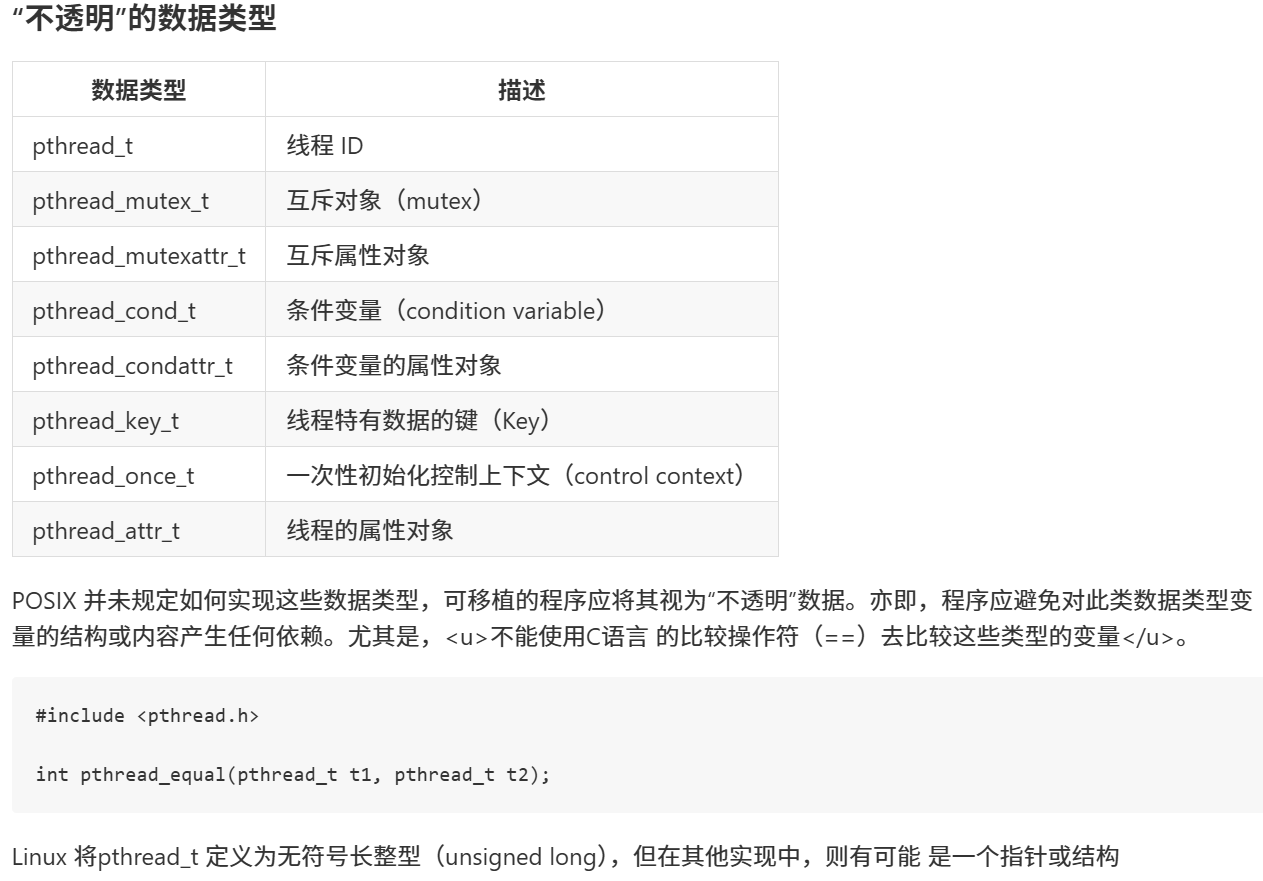

### 线程间参数传递

#### 常规参数传递方式

字符串传递（安全方式）
````C
void *func(void *arg) {
    char *str = (char *)arg;  // 将void*转换为char*
    printf("%s\n", str);
    pthread_exit(NULL);
}

int main() {
    char *str = "Hello Thread!";
    pthread_create(&tid, NULL, func, (void*)str);  // 可以显式转换
    // 或者直接传递（隐式转换）
    pthread_create(&tid, NULL, func, str);
}

#### 整型数据传递的两种方法

方法一：直接强制转换（不推荐）
````C
void *func(void *arg) {
    int value = (int)arg;  // void* -> int
    printf("arg:%d\n", value);
    pthread_exit(NULL);
}

int main() {
    int a = 10;
    // 警告：将int直接转换为void*
    pthread_create(&tid, NULL, func, (void*)a);
}
````
编译器会警告（int到指针的转换），且大小可能不匹配（32位系统可能正常，64位系统有问题）

方法二：推荐的安全方式 - 使用指针
````c
void *func(void *arg) {
    int *p = (int*)arg;  // 获取整型指针
    printf("value:%d\n", *p);  // 解引用获取值
    pthread_exit(NULL);
}

int main() {
    int a = 10;
    // 传递变量的地址
    pthread_create(&tid, NULL, func, &a);
    // 注意：要确保在线程使用时a仍然有效
}
````

方法三：动态分配内存（最安全）
````c
void *func(void *arg) {
    int *value = (int*)arg;
    printf("value:%d\n", *value);
    free(value);  // 使用后释放内存
    pthread_exit(NULL);
}

int main() {
    int *data = malloc(sizeof(int));
    *data = 10;
    pthread_create(&tid, NULL, func, data);
    // 注意：不要在main中free，在线程函数中free
}
````

#### 复杂数据结构传递


In [ ]:
typedef struct {
    int id;
    char name[20];
    float score;
} Student;

void *func(void *arg) {
    Student *stu = (Student*)arg;
    printf("ID:%d, Name:%s, Score:%.2f\n", 
           stu->id, stu->name, stu->score);
    pthread_exit(NULL);
}

int main() {
    Student stu = {1, "Alice", 95.5};
    pthread_create(&tid, NULL, func, &stu);
    // 或者动态分配
    Student *stu2 = malloc(sizeof(Student));
    stu2->id = 2;
    strcpy(stu2->name, "Bob");
    stu2->score = 88.5;
    pthread_create(&tid2, NULL, func, stu2);
}


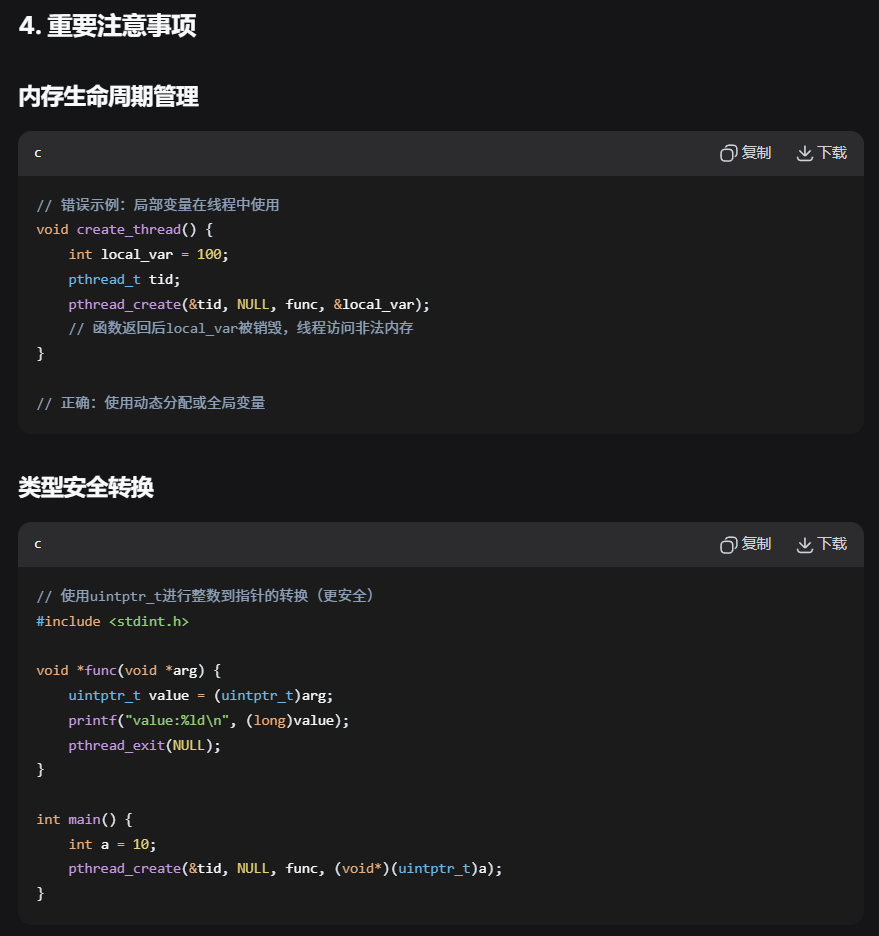

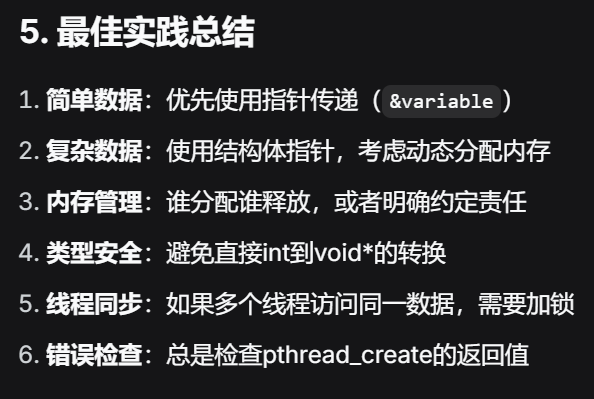

### 连接已终止线程

pthread_join函数
````c
#include <pthread.h>

int pthread_join(pthread_t thread, void **retval);
````
- 功能：等待 thread 指定的线程终止
- 参数
    - pthread_t thread
        - thread 指定的线程必须是可连接的
    - void **retval
        - 如果 retval 不是 NULL，则 pthread_join() 复制目标线程的退出状态到 retval 指向的位置
        - 如果目标线程已取消，则PTHREAD_CANCELED放置在 retval 指向的位置。
- ps: 注意事项
    - 如果该线程已终止，则 pthread_join() 立即返回
    - 如果多个线程同时尝试与同一线程连接，则结果是不确定的。


连接正常终止的线程

In [ ]:
#include <pthread.h>
#include <stdio.h>
#include <stdlib.h>
#include <errno.h>

void *func (void *arg) {
	pthread_exit("thread exit");
}

int main(int argc, const char *argv[])
{
	pthread_t tid;
	int ret = pthread_create(&tid, NULL, func, NULL);
	if(ret != 0){
		errno = ret;
		perror("pthread_create");
		exit(EXIT_FAILURE);
	}
	void *retval;
	ret = pthread_join(tid, &retval);
	if(ret != 0){
		errno = ret;
		perror("pthread_create");
		exit(EXIT_FAILURE);
	}
	printf("retval:%s\n", (char *)retval);

	return 0;
}


链接被取消的线程

In [ ]:
#include <pthread.h>
#include <stdio.h>
#include <stdlib.h>
#include <errno.h>
#include <unistd.h>

void *func (void *arg) {
	sleep(10);
	pthread_exit("thread exit");
}

int main(int argc, const char *argv[])
{
	pthread_t tid;
	int ret = pthread_create(&tid, NULL, func, NULL);
	if(ret != 0){
		errno = ret;
		perror("pthread_create");
		exit(EXIT_FAILURE);
	}
	void *retval;
	sleep(1);
	pthread_cancel(tid);
	ret = pthread_join(tid, &retval);
	if(ret != 0){
		errno = ret;
		perror("pthread_create");
		exit(EXIT_FAILURE);
	}
	printf("retval:%d\n", (int)retval);

	return 0;
}


连接强转的整型作为返回值的线程

In [ ]:
#include <pthread.h>
#include <stdio.h>
#include <stdlib.h>
#include <errno.h>
#include <unistd.h>

void *func (void *arg) {
	int a = 10;
	pthread_exit(a);
}

int main(int argc, const char *argv[])
{
	pthread_t tid;
	int ret = pthread_create(&tid, NULL, func, NULL);
	if(ret != 0){
		errno = ret;
		perror("pthread_create");
		exit(EXIT_FAILURE);
	}
	void *retval;
	ret = pthread_join(tid, &retval);
	if(ret != 0){
		errno = ret;
		perror("pthread_create");
		exit(EXIT_FAILURE);
	}
	printf("retval:%d\n", (int)retval);

	return 0;
}

/*将经强制转换的整型数作为线程函数的返回值时，必须小心谨慎。
取消线程时的返回值PTHREAD_CANCELED和导致无法判定，
线程的终止方式，是被取消了还是正常终止。*/


其它注意事项

In [ ]:
若线程并未分离，则必须使用ptherad_join()来进行连接，以免成为“僵尸线程”

线程之间的关系是对等的（peers），进程中的任意线程均可以调用pthread_join()与该进程的任何其他线程连接起来


### 线程同步与互斥

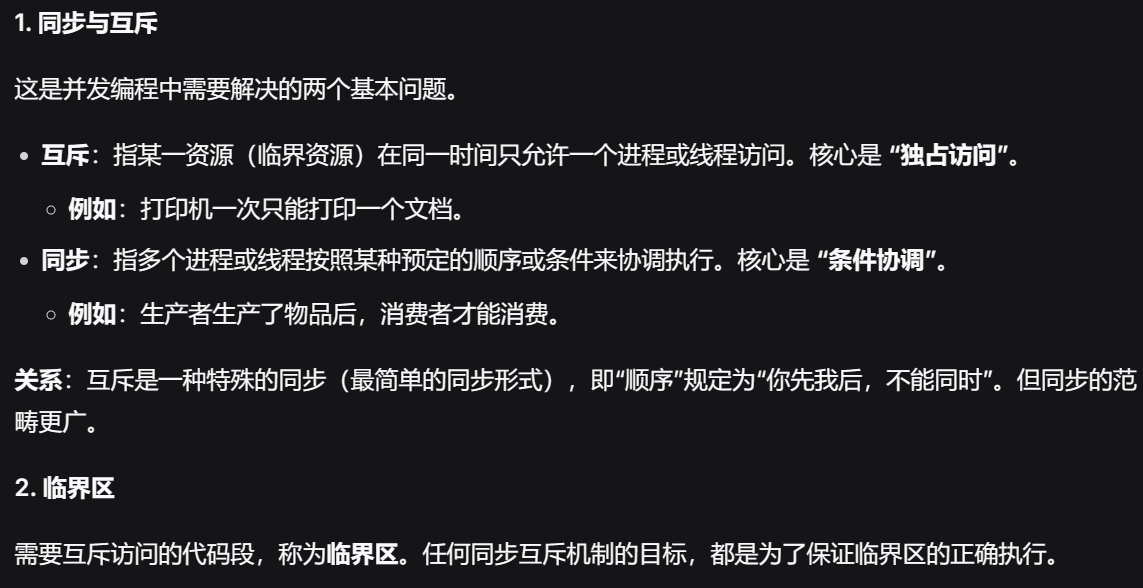

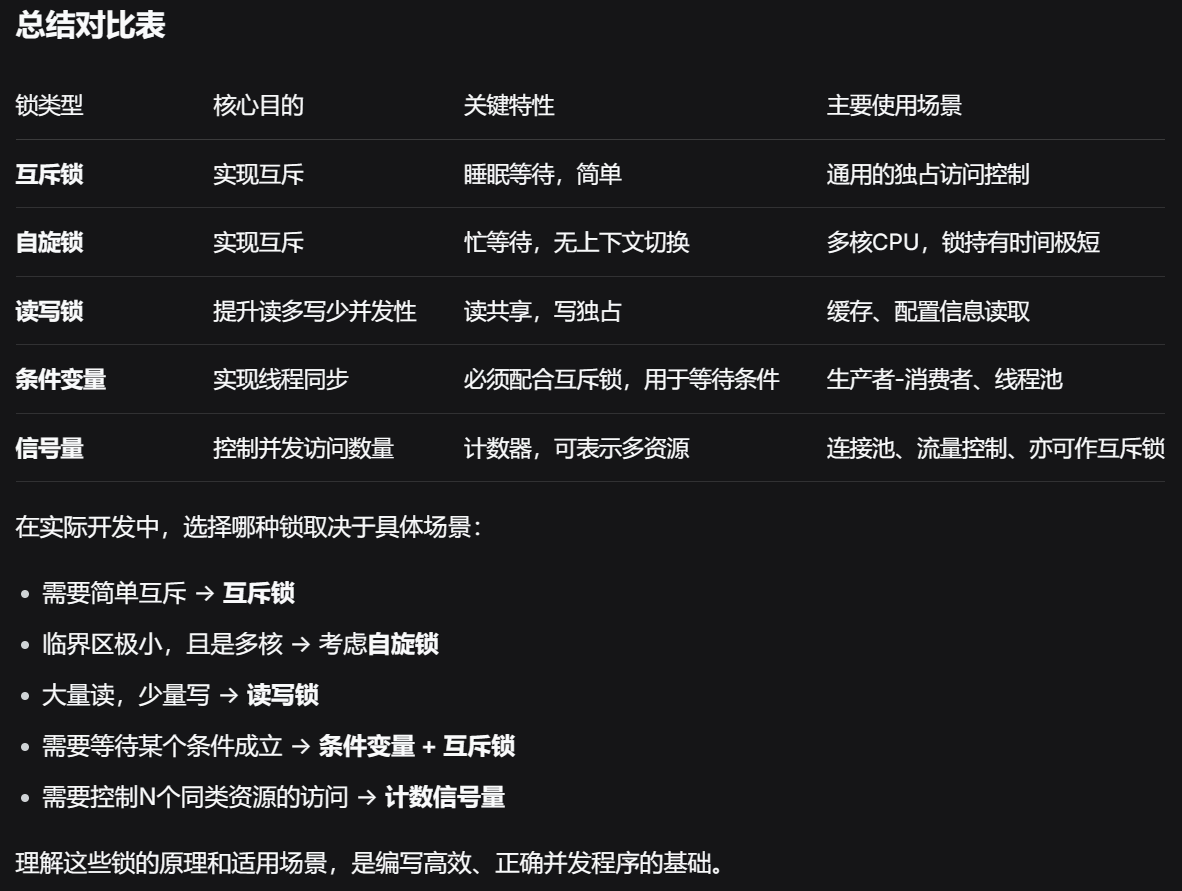

#### 全局变量同步问题

###### 见5.concurrent_programming/2.线程控制/一个问题代码（全局变量同步问题）.c

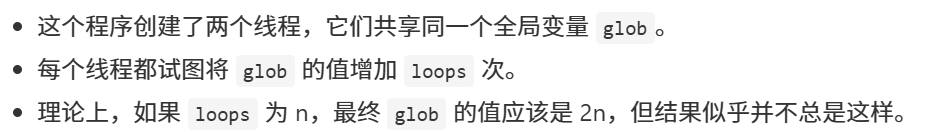

#### 互斥量概述：

互斥量（Mutex，Mutual Exclusion） 是操作系统和并发编程中用于`保护共享资源`，防止多个线程（或进程）同时访问同一资源而导致数据不一致的同步机制。
核心概念
- 互斥
    - 确保同一时间只有一个线程可以进入被保护的代码区域（临界区）。
- 排他性
    - 一旦一个线程获取了互斥量，其他线程必须等待该线程释放互斥量后才能获取。

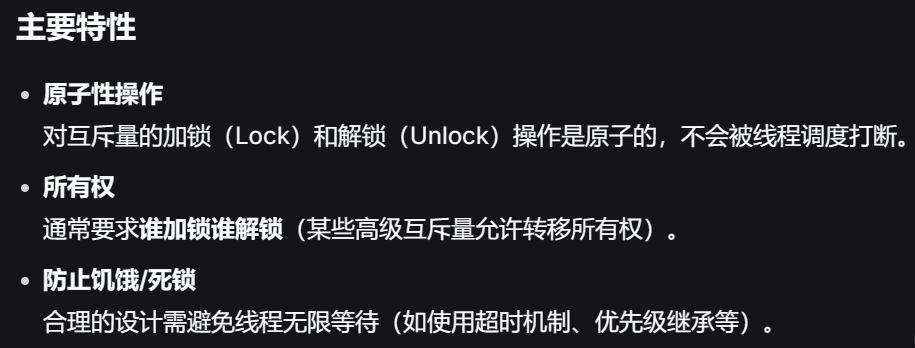

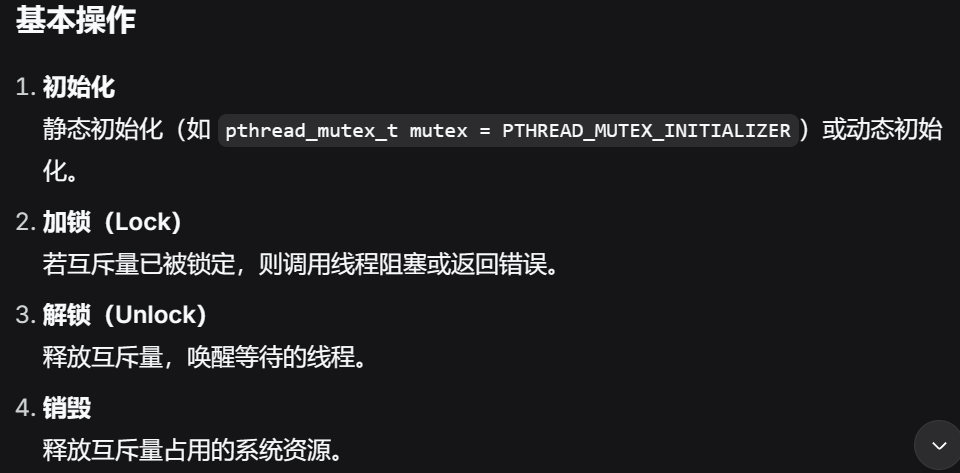

#### 静态初始化的互斥量

互斥量是属于`pthread_mutex_t`类型的变量。在使用之前必须对其初始化。对于静态分配的互斥量而言，可如下例所示，将`PTHREAD_MUTEX_INITIALIZER`赋给互斥量。

In [ ]:
// 静态初始化
#include <pthread.h>

pthread_mutex_t mutex = PTHREAD_MUTEX_INITIALIZER;


##### 加锁和解锁互斥量

初始化之后，互斥量处于未锁定状态。函数`pthread_mutex_lock()`可以锁定某一互斥量，而函数`pthread_mutex_unlock()`则可以将一个互斥量解锁。

In [ ]:
#include <pthread.h>

int pthread_mutex_lock(pthread_mutex_t *mutex);
int pthread_mutex_trylock(pthread_mutex_t *mutex); //极少使用不必深究
int pthread_mutex_unlock(pthread_mutex_t *mutex);


- 要锁定互斥量，在调用`pthread_mutex_lock()`时需要指定互斥量。
- 如果互斥量当前处于未锁定状态，该调用将锁定互斥量并立即返回。
- 如果其他线程已经锁定了这一互斥量，那么 `pthread_mutex_lock()`调用会一直堵塞，直至该互斥量被解锁，到那时，调用将锁定互斥量并返回。

如果发起 pthread_mutex_lock()调用的线程自身之前已然将目标互斥量锁定，对于互斥量的默认类型而言，可能会产生两种后果—视具体实现而定：
- 线程陷入死锁（deadlock），因试图锁定已为自己所持有的互斥量而遭到阻塞；
- 或者调用失败，返回EDEADLK错误。在Linux上，默认情况下线程会发生死锁。


避免嵌套加锁，出现死锁

In [ ]:
e.g.
#include <pthread.h>
#include <stdio.h>
#include <stdlib.h>
// 关键词：同步机制、互斥量解决同步问题、临界区、临界资源、竞态条件、原子操作、自增运算的非原子性

// TODO  初始化互斥量
pthread_mutex_t mutex = PTHREAD_MUTEX_INITIALIZER; // 第一次初始化互斥量，mutex锁为解锁状态

// TODO  定义临界资源
static int glob;  // 全局变量，被所有线程共享

// 线程函数
void *ThreadFunc(void *arg) {
    ...
    // TODO  加锁、临界区代码保护临界资源、解锁
    for (j=0; j<loops; j++){
        // 加锁
        pthread_mutex_lock(&mutex); // 若mutex锁为解锁状态，则加锁成功，若mutex锁为锁定状态，则**阻塞等待**直到mutex锁被解锁
        
        // 临界区代码，同一时刻只能有一个线程进入临界区
        {
        glob++;
        }
        // 解锁
        pthread_mutex_unlock(&mutex);
    }

}

int main(int argc, const char *argv[])
{
    ...


    // TODO  销毁互斥量
    pthread_mutex_destroy(&mutex); // 销毁互斥量，释放相关资源
    
    ...

    return 0;
}


函数`pthread_mutex_unlock()`将解锁之前已遭调用线程锁定的互斥量。以下行为均属错误：
- 对处于未锁定状态的互斥量进行解锁
- 解锁由其他线程锁定的互斥量

如果有不止一个线程在等待获取由函数 `pthread_mutex_unlock()`解锁的互斥量，则**无法判断**究竟哪个线程将如愿以偿。

#### 动态初始化的互斥量

必须使用函数`pthread_mutex_init()`的几种情况
- 动态分配于堆中的互斥量。例如，**动态创建针对某一结构的链表，表中每个结构都包含一个pthread_mutex_t 类型的字段来存放互斥量，借以保护对该结构的访问。**

- 互斥量是在栈中分配的自动变量。

- 初始化经由静态分配，且不使用默认属性的互斥量。

`pthread_mutex_init()`函数

In [ ]:
#include <pthread.h>
int pthread_mutex_init(pthread_mutex_t *restrict mutex,
           const pthread_mutexattr_t *restrict attr);


- **mutex**：指定函数执行初始化操作的目标互斥量。

- **attr**： 是指向`pthread_mutexattr_t`类型对象的指针，该对象在函数调用之前已经过了初始化处理，用于定义互斥量的属性。若将`attr`参数置为`NULL`，则该互斥量的各种属性会取默认值。

**初始化一个业已初始化的互斥量将导致未定义的行为，应当避免这一行为。**

**如果 `pthread_mutex_init()` 的 `attr` 参数指定的值不引用初始化的互斥锁属性对象，则行为未定义。**


#### 互斥量的销毁

当不再需要经由自动或动态分配的互斥量时，应使用 pthread_mutex_destroy()将其销毁。
````c
#include <pthread.h>
int pthread_mutex_destroy(pthread_mutex_t *mutex);
````
如果 `pthread_mutex_destroy()` 的 `mutex` 参数指定的值不引用初始化的互斥锁，则行为未定义。


#### 互斥量的其它细节

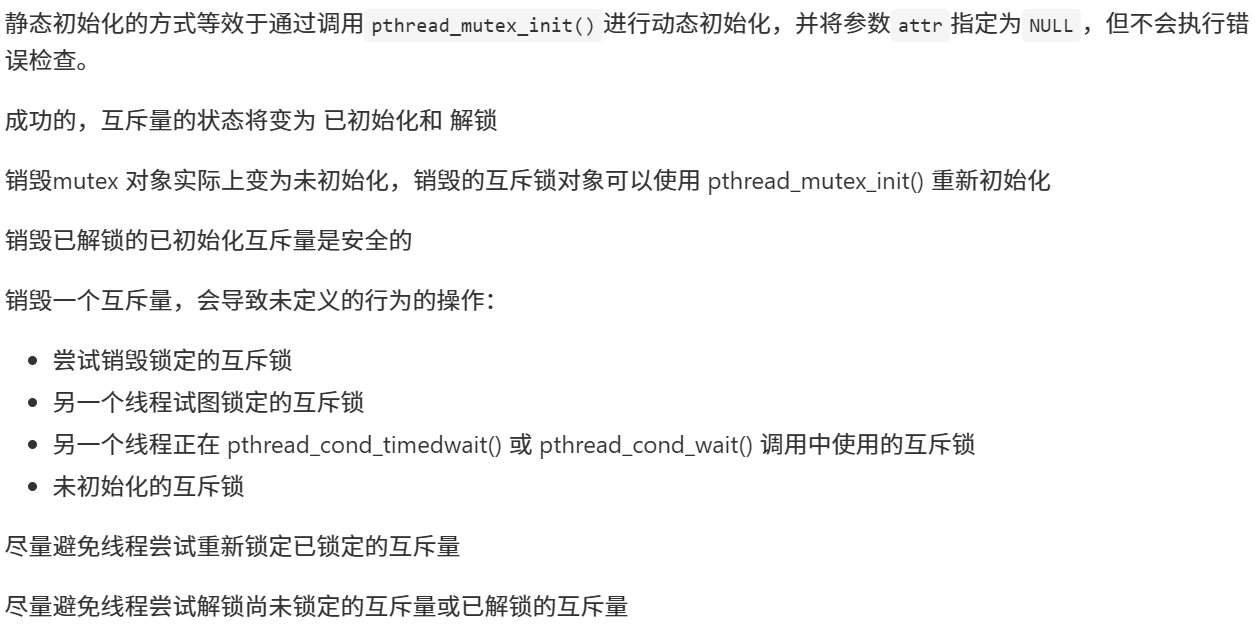

#### 读写锁

读/写锁（Read-Write Lock）是另外一种避免多个线程同时修改临界资源的一种互斥机制。

##### 读写锁特点

不同于互斥锁（mutual exclusion）读/写锁提供了两种加锁方式：**读锁和写锁**。

`读锁`具有`共享`的特点，所谓共享指的是所有以读的方式加锁的临界资源可以同时被访问。所以读锁也被称为`共享锁`

`写锁`具有`独占`的特点，这点和互斥锁是一样的，所以写锁也被称为`独占锁`

- 初始化读写锁
```c
    int pthread_rwlock_init(pthread_rwlock_t *restrict rwlock,
            const pthread_rwlockattr_t *restrict attr);

    pthread_rwlock_t rwlock = PTHREAD_RWLOCK_INITIALIZER;
```

- 销毁读写锁
```c
    int pthread_rwlock_destroy(pthread_rwlock_t *rwlock);
```

- 加锁与解锁
```c
    int pthread_rwlock_rdlock(pthread_rwlock_t *rwlock); // 读锁方式加锁
    int pthread_rwlock_wrlock(pthread_rwlock_t *rwlock); // 写锁方式加锁
    int pthread_rwlock_unlock(pthread_rwlock_t *rwlock); // 解锁
```

#### 条件变量（高级的同步机制，生产者-消费者、读写锁的实现基础）

##### 引入：生产者与消费者问题

In [ ]:
    生产者与消费者问题是多线程编程领域中的一个经典问题，主要用来描述一个或多个生产者线程和一个或多个消费者线程共享有限缓冲区资源时的同步问题。
这个问题的核心在于如何保持生产者和消费者之间的协调，确保当缓冲区已满时生产者停止生产，而当缓冲区已空时消费者停止消费，以避免出现资源浪费或死锁的情况。


主要概念：

    生产者：负责生成数据并将其放入共享的缓冲区。

    消费者：负责从共享的缓冲区中取出数据并处理。

    缓冲区：一个有限的资源，用于暂时存储生产者产生的数据，直到消费者取走处理。


问题的关键点：

    资源共享：生产者和消费者共享同一个缓冲区，需要协调访问以确保线程安全。

    同步机制：防止生产者在缓冲区满时继续生产，同时防止消费者在缓冲区空时继续消费。

    互斥：确保在任意时刻只有一个线程（生产者或消费者）能够访问缓冲区。


解决方案（解决生产者与消费者问题通常使用以下几种同步机制）：

    信号量（Semaphore）：用于控制对共享资源的访问，通过信号量的P操作（等待）和V操作（信号）来实现同步。

    条件变量（Condition Variable）：条件变量通常与互斥锁（Mutex）结合使用，用于线程之间的同步。条件变量允许线程在某个条件不满足时等待，而当条件满足时被唤醒。

    队列（Queue）：使用一个线程安全的队列来管理缓冲区，生产者将数据放入队列，消费者从队列中取出数据。队列通常内部已经实现了同步机制，使用起来更加方便。



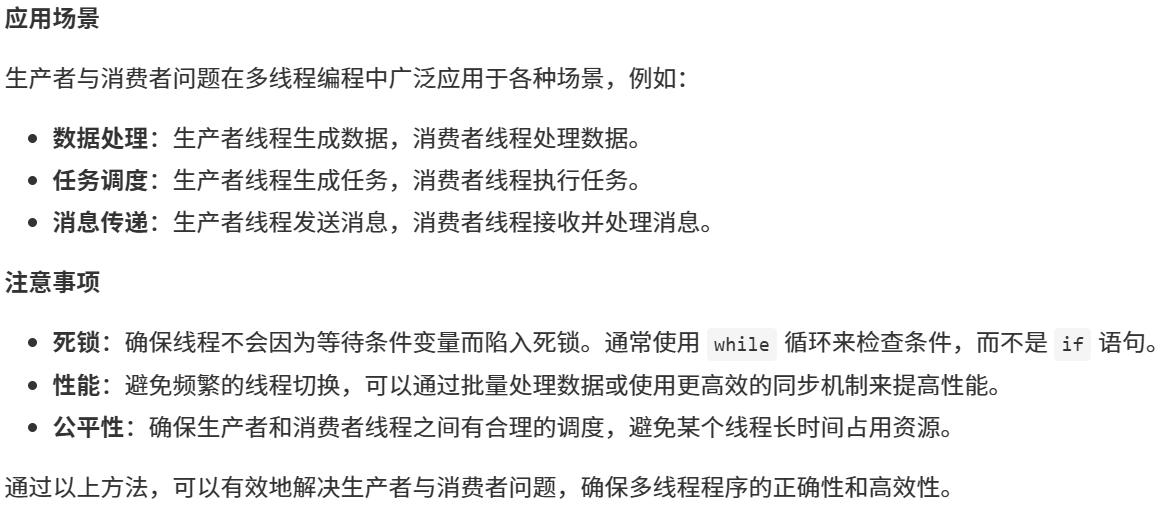

##### 什么是条件变量？

In [ ]:
条件变量（''condition variable'' 的缩写）是一种同步设备

条件变量允许一个线程就某个共享变量（或其他共享资源）的状态变化通知其他线程，并让其他线程等待（堵塞于）这一通知。


##### 条件变量是怎样工作的？

**第一步：初识化**
- 静态分配
```c
    #include <pthread.h>

    pthread_cond_t cond = PTHREAD_COND_INITIALIZER;
```
- 动态分配
```c
    #include <pthread.h>

    int pthread_cond_init(pthread_cond_t *restrict cond,
            const pthread_condattr_t *restrict attr);
```

**第二步：使用发送信号**
```c
    #include <pthread.h>

    int pthread_cond_signal(pthread_cond_t *cond);


    #include <pthread.h>

    int pthread_cond_broadcast(pthread_cond_t *cond);
```

**第三步：接收信号**
```c
    #include <pthread.h>

    int pthread_cond_timedwait(pthread_cond_t *restrict cond,
        pthread_mutex_t *restrict mutex,
        const struct timespec *restrict abstime);
    int pthread_cond_wait(pthread_cond_t *restrict cond,
        pthread_mutex_t *restrict mutex);
```
`pthread_cond_wait()`函数的功能说明：
- 解锁互斥量`mutex`

- 堵塞调用线程，直至另一线程就条件变量`cond`发出信号

- 重新锁定`mutex`
第2步和第3步同属于一个原子操作

**第四步：销毁**
```c
    #include <pthread.h>

    int pthread_cond_destroy(pthread_cond_t *cond);
```
`pthread_cond_destroy()`函数应销毁 `cond` 指定的`给定条件变量`;对象实际上变为未初始化。

实现可能会导致 `pthread_cond_destroy()` 将 `cond` 引用的对象设置为无效值。

销毁的条件变量对象可以使用 `pthread_cond_init()` 重新初始化;

在对象被销毁后以其他方式引用该对象的结果是未定义的。

销毁当前没有线程被阻塞的初始化条件变量应该是安全的。

**尝试销毁当前阻止其他线程的条件变量会导致未定义的行为**


##### 条件变量的虚假唤醒问题

虚假唤醒（Spurious Wakeup） 是指在`没有明确通知的情况下`，等待在条件变量上的线程被`意外唤醒`的现象。这种唤醒不是由于其他线程调用 `notify_one()` 或 `notify_all()` 引起的，而是`操作系统或底层实现的原因导致`的。

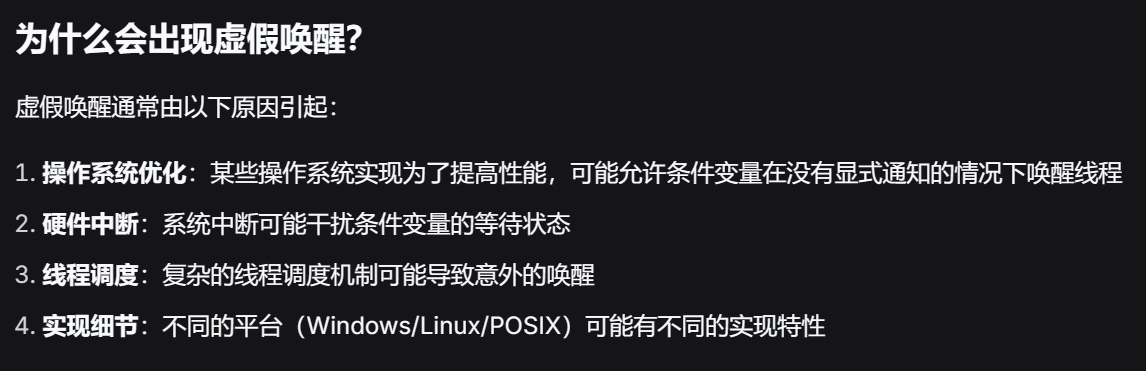

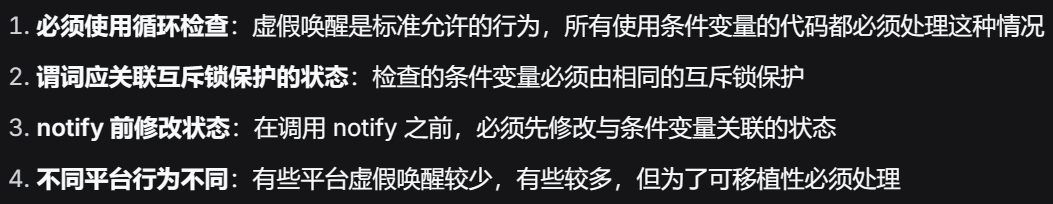

总是使用 while 循环（或带谓词的 wait）来检查条件，永远不要相信单次的 if 检查。这种模式不仅防止虚假唤醒，还能使代码更健壮，能够处理各种意外的唤醒情况

### 线程的取消

In [ ]:
int pthread_cancel(pthread_t thread);


`pthread_cancel`用到向一个线程发送一个取消的请求。注意，**只是一个请求**，类似进程的信号机制，只是向线程发送请求！ 目标线程会发生什么？何时发生？这些都取决于被请求的线程。也就是线程取消的`状态（state）`和`类型（type）`

#### 取消状态及类型

##### 线程的取消状态

In [ ]:
// 线程默认会启用取消的功能，如果想禁用此功能：可以使用下面的函数
int pthread_setcancelstate(int state, int *oldstate);


`state`可以是以下两个值之一：

- `PTHREAD_CANCEL_ENABLE`: 启用线程取消（默认状态）。
- `PTHREAD_CANCEL_DISABLE`: 禁用线程取消。

`oldstate`: 指向一个 int 类型变量的指针，用于保存线程之前的取消状态。如果不需要保存旧状态，可以将其设置为 NULL。

##### 线程取消的的类型

In [ ]:
int pthread_setcanceltype(int type, int *oldtype);


`type`也是两个值之一：

- `PTHREAD_CANCEL_DEFERRED`: 取消请求将被推迟到<u><font style="color:rgba(255, 200, 0, 1);">取消点</font></u>（默认类型）。

- `PTHREAD_CANCEL_ASYNCHRONOUS`: 取消请求会被立即响应，即<u><font style="color:rgba(255, 200, 0, 1);">异步取消</font></u>。

`oldtype`和`oldstate`类似，它保存线程之前的取消类型。如果不需要保存旧类型，也是将其设置为NULL。

#### 取消点

取消点是线程在执行过程中检查取消请求的**特定位置**。

在线程被设置为响应取消请求时，它会在这些预定义的取消点检查是否有取消请求，并据此决定是否终止执行。

取消点的存在可以让线程在安全的位置中止其操作，**避免在不可预测的状态下取消线程**。

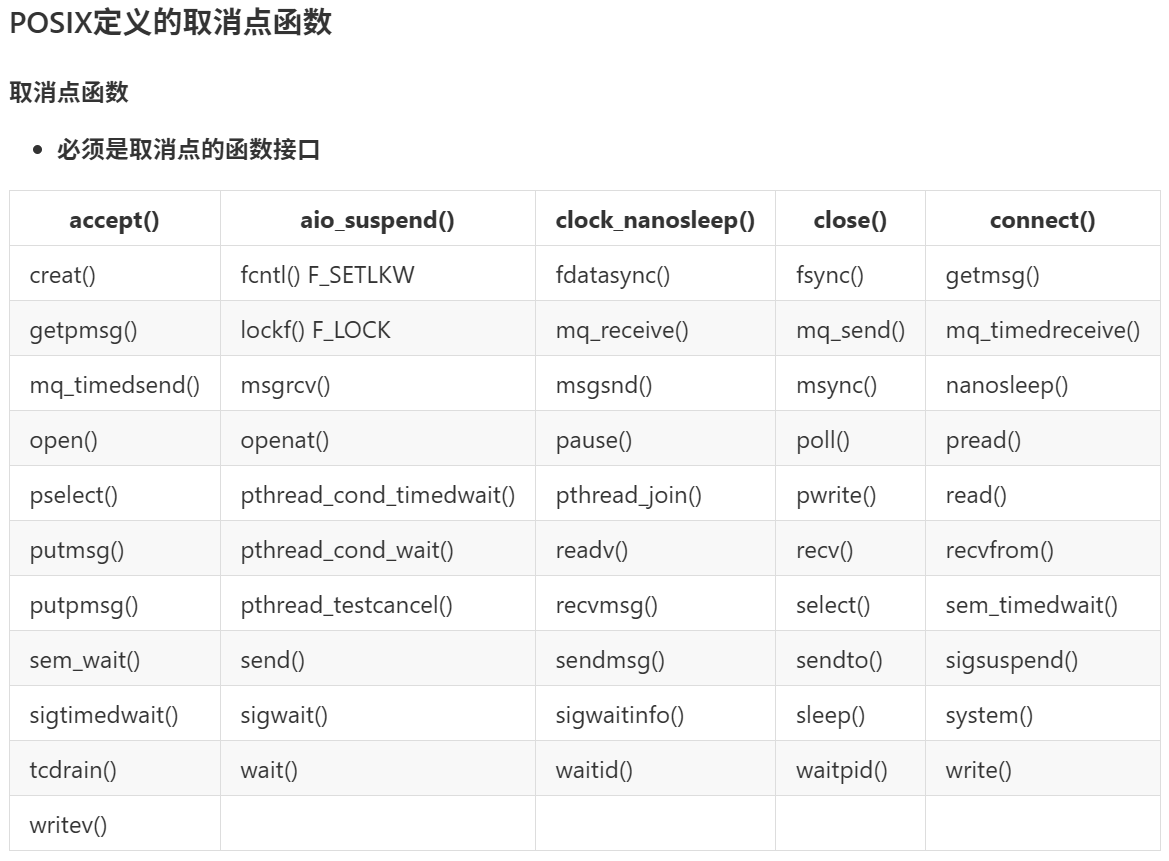

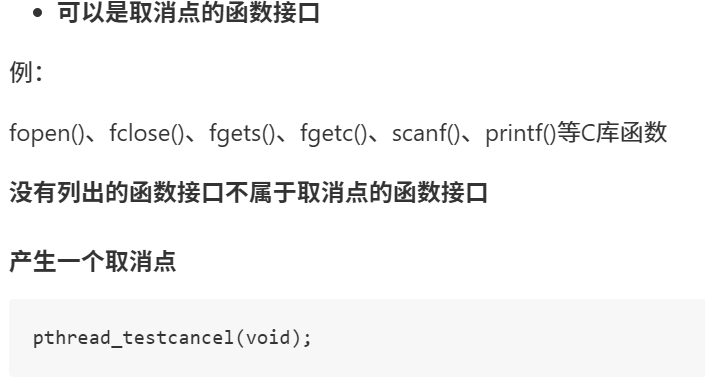

##### 取消点应用

线程运行到取消点被取消

In [ ]:
#include <pthread.h>
#include <stdio.h>
#include <stdlib.h>
#include <unistd.h>

void* thread_func(void* arg) {
	printf("线程开始运行\n");

	// 模拟长时间运行的操作，并在某些点处设置取消点
	for (int i = 0; i < 10; ++i) {
		printf("线程运行中：%d\n", i);
		sleep(1);
	}

	printf("线程正常结束\n");
	pthread_exit(NULL);
}

int main() {
	pthread_t tid;
	// 创建线程
	pthread_create(&tid, NULL, thread_func, NULL);
	sleep(3);
	pthread_cancel(tid);

	// 等待线程结束
	void *retval;
	pthread_join(tid, &retval);
	if(PTHREAD_CANCELED == (int)retval) {
		printf("线程被取消\n");
	}
	printf("主线程结束\n");
	return 0;
}


没有取消点线程不会被取消

In [ ]:
#include <pthread.h>
#include <stdio.h>
#include <stdlib.h>
#include <unistd.h>

void* thread_func(void* arg) {
	// 模拟长时间运行的操作，并在某些点处设置取消点
	for (int i = 0; i < 10; ++i) {
		for(unsigned long int j = 0; j < 1000000000; j++);
	}
	return NULL;
}

int main() {
	pthread_t tid;
	// 创建线程
	pthread_create(&tid, NULL, thread_func, NULL);
	sleep(1);
	pthread_cancel(tid);

	// 等待线程结束
	void *retval;
	pthread_join(tid, &retval);
	if(PTHREAD_CANCELED == (int)retval) {
		printf("线程被取消\n");
	} else {
		printf("线程正常终止\n");
	}
	printf("主线程结束\n");
	return 0;
}


#### 清理函数

In [ ]:
#include <pthread.h>

void pthread_cleanup_push(void (*routine)(void *), void *arg);
void pthread_cleanup_pop(int execute);


这些函数用于管理调用线程的线程取消清理处理程序栈。清理处理程序是一个在线程被取消时（或下述其他情况下）自动执行的函数。例如，它可以用于解锁互斥锁，使进程中的其他线程能够使用该资源。

`pthread_cleanup_push()`
- 将指定的 routine 函数压入清理处理程序栈的顶部。当后续调用 routine 时，会使用 arg 作为其参数。

`pthread_cleanup_pop()`
- 移除栈顶的清理处理程序 routine，并根据 execute 参数决定是否执行它（若 execute 非零则执行）。

##### 触发清理处理程序的情况

清理处理程序会在以下情况下从栈中弹出并执行：
- **线程被取消时**：所有栈中的清理处理程序会按照压栈的相反顺序依次弹出并执行。
- **线程调用 pthread_exit(3) 终止时**：所有清理处理程序按上述方式执行（注意：若线程通过从线程启动函数直接返回而终止，则不会调用清理处理程序）。
- **显式调用 pthread_cleanup_pop() 且 execute 非零时**：弹出并执行栈顶的清理处理程序。

##### 实现限制与注意事项
- 根据 POSIX.1 标准，`pthread_cleanup_push()` 和 `pthread_cleanup_pop()` 可能被实现为包含 { 和 } 的宏。因此，调用者必须确保这两个函数在同一函数内、相同的词法嵌套层级中成对使用（即清理处理程序仅在代码的特定区块内生效）。

### 线程池（多线程应用）

###### 前面知识点综合应用

线程池是一种线程管理机制，它可以在程序启动时创建一定数量的线程，这些线程可以被重复使用来执行任务，而不是每次都创建新线程。线程池可以帮助程序避免频繁创建和销毁线程的开销，提高程序的性能和响应速度。

#### 线程池的四大核心组件

1. 任务队列（待办清单）

    - 结构：链表实现的先进先出（FIFO）队列
    - 每个任务包含：
    ```c
        struct Task {
            void (*function)(void *); // 任务函数（做什么）
            void *arg;                // 参数（用什么做）
            struct Task *next;        // 下一个任务
        };
    ```

2. 工作线程（员工团队）

    - 固定数量的线程（如4个）
    - 每个线程的行为：
    ```ini
        while True:
            等待任务 -> 取出任务 -> 执行任务
    ```

3. 管理者（协调工具）
    - `互斥锁 (mutex)`：防止多人同时操作任务队列
    （就像餐厅的点餐机一次只能一个人操作）
    - `条件变量 (condition variable)`：通知空闲线程有新任务
    （类似厨房的"有新订单"提示铃）
        - 用于线程之间的同步通信
        - 当任务队列为空时，工作线程等待
        - 当有新任务加入时，通知工作线程

4. 控制开关

    - `shutdown`标志：安全关闭线程池的信号（类似打烊时让员工完成现有订单后下班）

#### 线程池实现步骤

**第一步：创建线程池**

```c
ThreadPool *pool = malloc(sizeof(ThreadPool)); 
// 相当于开店：准备场地、雇佣员工、准备工具
```
- 初始化锁和条件变量
- 创建固定数量的线程
- 所有线程执行worker函数

**第二步：工作线程的行为**

```c
void *worker(void *arg) {
    while(1) {
        锁住互斥锁;
        while(没任务 && 不关闭) {
            等待条件变量; // 进入休眠
        }
        if(需要关闭) break;
        取出任务;
        解锁互斥锁;
        
        执行任务函数(task->function);
        释放任务内存;
    }
}
```
**重点理解**：
- <u>`pthread_cond_wait()` 会自动释放锁，被唤醒时重新获得锁</u>
- <u>必须用while检查任务，不能用if（防止虚假唤醒）</u>


**第三步：添加任务**

```c
void add_task(ThreadPool *pool, 函数指针, 参数) {
    创建新任务节点;
    锁住互斥锁;
    将任务加入队列尾部;
    发送条件信号;
    解锁互斥锁;
}
```
**类比**：<u>顾客在前台下单，服务员把订单贴到厨房的任务板上，然后按铃提醒厨师。</u>


**第四步：销毁线程池**

- 1. 设置shutdown标志为1
- 2. 广播通知所有线程
- 3. 等待所有线程结束
- 4. 清理剩余任务
- 5. 销毁锁和条件变量

**安全关闭的关键**：
- <u>先通知，再等待</u>
- <u>确保没有线程卡在等待中</u>

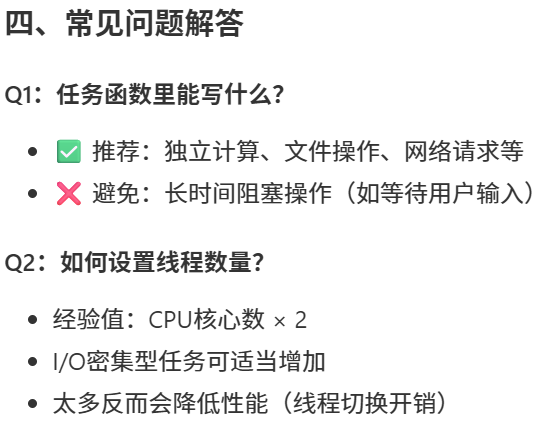

## 进程间通信

### 管道

管道是一个可用于进程间通信的单向数据通道

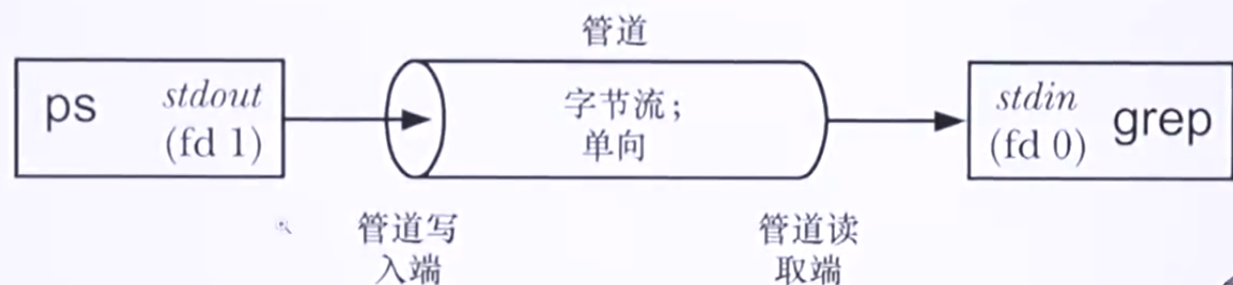

###### 管道如何工作

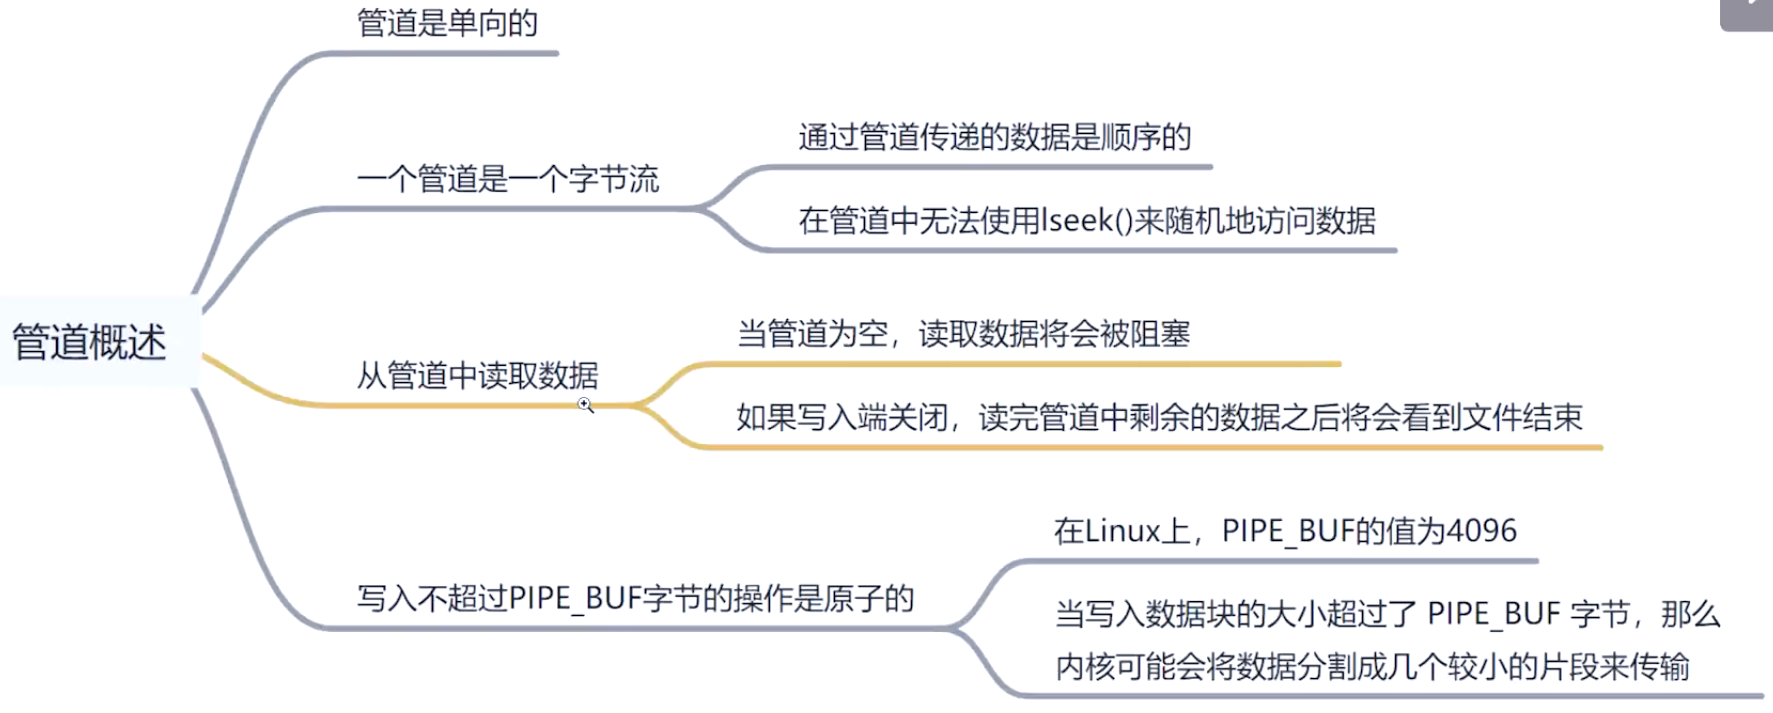

#### 管道的创建

```c
#include <unistd.h>
//pipe函数用于创建一个管道
int pipe(int pipefd[2]);
```
- 数组 pipefd 用于返回两个引用管道末端的文件描述符
- `pipefd[0]` 引用管道的读取端
- `pipefd[1]` 是指管道的写入端
- 写入管道写入端的数据由`内核缓冲`，直到从管道的读取端读取


##### 构建相关进程间通信的管道

- 使用`pipe()`创建完之后的管道

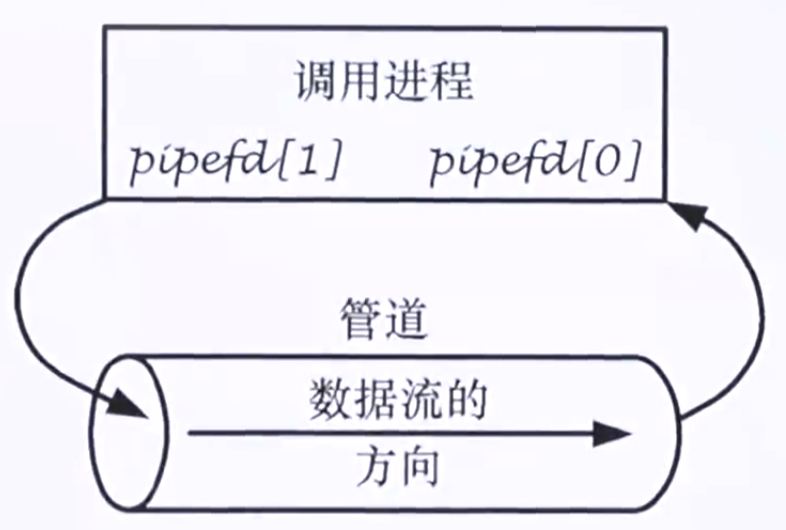

- 使用`fork()`实现进程间通信

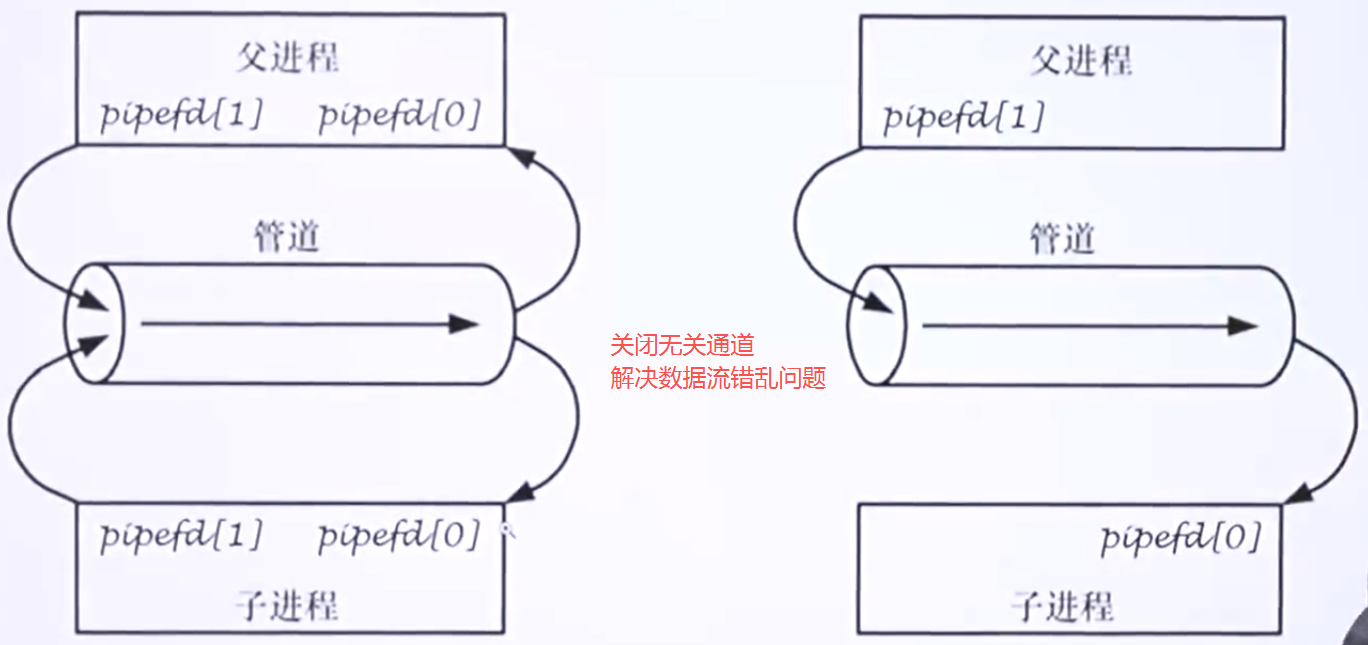

In [ ]:
#include <sys/types.h>
#include <sys/wait.h>
#include <stdio.h>
#include <stdlib.h>
#include <unistd.h>
#include <string.h>

int main(int argc, char *argv[])
{
	int pipefd[2];
	pid_t cpid;
	char buf;

	if (argc != 2) {
		fprintf(stderr, "Usage: %s <string>\n", argv[0]);
		exit(EXIT_FAILURE);
	}

	if (pipe(pipefd) == -1) {
		perror("pipe");
		exit(EXIT_FAILURE);
	}

	cpid = fork();
	if (cpid == -1) {
		perror("fork");
		exit(EXIT_FAILURE);
	}

	if (cpid == 0) {    /* Child reads from pipe */
		close(pipefd[1]);          /* Close unused write end */

		while (read(pipefd[0], &buf, 1) > 0)
			write(STDOUT_FILENO, &buf, 1);

		write(STDOUT_FILENO, "\n", 1);
		close(pipefd[0]);
		_exit(EXIT_SUCCESS);

	} else {            /* Parent writes argv[1] to pipe */
		close(pipefd[0]);          /* Close unused read end */
		write(pipefd[1], argv[1], strlen(argv[1]));
		close(pipefd[1]);          /* Reader will see EOF */
		wait(NULL);                /* Wait for child */
		exit(EXIT_SUCCESS);
	}
}


**关于读写顺序**

由于进程的执行谁先谁后是由系统决定的，所以读写没有严格顺序

同一时刻只有一个写端，只有一个读端

**读端阻塞问题**

In [ ]:
#include <unistd.h>
#include <stdio.h>

int main(int argc, const char *argv[])
{
	int pfd[2];
	char buf[1024] = {};
	pipe(pfd);

	switch(fork()) {
	case 0:
		close(pfd[0]);
		close(pfd[1]);
		printf("子进程退出\n");
		return 1;
		break;
	default:
		// 写端并未全部关闭，所以这里会一直阻塞
		read(pfd[0], buf, sizeof(buf) ); 
		printf("读到数据啦\n");
		close(pfd[0]);
		close(pfd[1]);
		return 1;
	}
	return 0;
}


写端全部关闭读端才能读到文件末尾，在`read()`之前，父进程的写端并没有关闭，所以`read()`不会读到文件末尾，会一直阻塞。

**管道破裂问题**

向一个没有读端的管道写入数据会导致管道破裂，管道破裂时进程会收到SIGPIPE的信号。进程对SIGPIPE信号的默认处置方式是终止进程

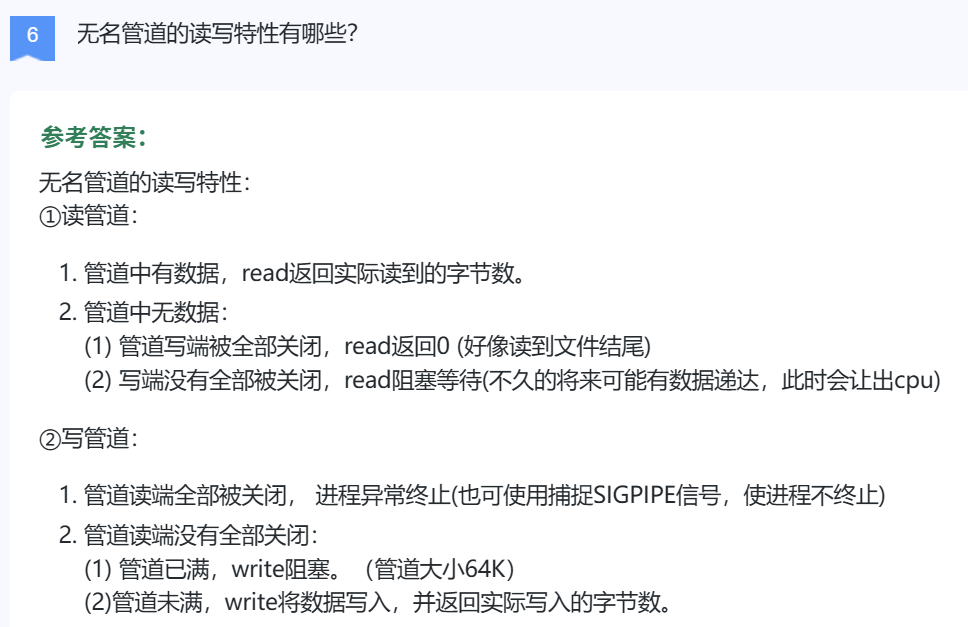

### 消息队列

类似管道，消息队列也是内核维护的一种允许进程交换数据的一种通信方式，但与管道不同的是消息队列并不是简单的字节流，而是一种消息的形式的数据结构

### 共享内存

在Linux/X86-32中典型的进程内存布局如下：

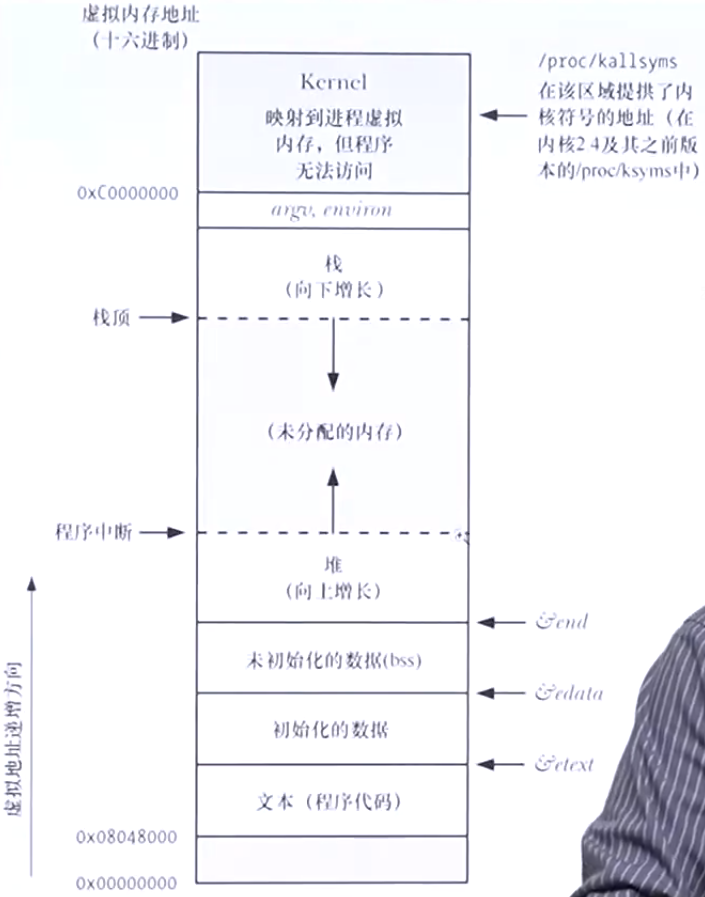

#### 内存映射（POSIX共享内存是基于内存映射实现的）

In [ ]:
内存映射是将文件或设备的内容映射到进程的地址空间，使进程可以直接访问文件或设备的内容，而无需进行系统调用。



##### Linux内核如何为一个进程分配内存空间

In [ ]:
在Linux内核中，为进程分配内存空间涉及多个步骤和机制，主要包括以下关键点：

1. 虚拟内存管理
Linux使用虚拟内存管理，每个进程都有独立的虚拟地址空间，通常分为用户空间和内核空间。用户空间供进程使用，内核空间由内核管理。

2. 内存描述符 (`mm_struct`)
每个进程的虚拟内存信息由`mm_struct`结构体管理，包含内存映射、堆、栈等信息。

3. 内存映射
进程的内存映射通过`vm_area_struct`结构体描述，记录虚拟内存区域的起始、结束地址、权限等。常见的内存区域包括：
- **代码段**：存放可执行代码。
- **数据段**：存放全局和静态变量。
- **堆**：动态分配的内存。
- **栈**：用于函数调用和局部变量。

4. 内存分配
内存分配主要通过以下系统调用：
- **`brk` 和 `sbrk`**：调整堆的大小。
- **`mmap`**：创建新的内存映射，可用于文件映射或匿名内存分配。

5. 缺页异常处理
当进程访问未映射的虚拟内存时，触发缺页异常，内核通过以下步骤处理：
- **检查访问权限**：确认访问是否合法。
- **分配物理内存**：若合法，分配物理页并更新页表。
- **恢复执行**：进程继续执行。

6. 页面回收
当物理内存不足时，内核通过页面回收机制释放内存，包括：
- **页面置换**：将不常用的页面换出到交换空间。
- **内存压缩**：压缩内存页以减少使用。

7. 内核内存分配
内核使用`kmalloc`、`vmalloc`等函数分配内存，`kmalloc`用于小块连续内存，`vmalloc`用于大块不连续内存。

总结
Linux内核通过虚拟内存管理、内存描述符、内存映射、缺页异常处理和页面回收等机制为进程分配和管理内存空间，确保进程高效、安全地使用内存。


##### `mmap()`四种映射类型

**文件映射（MAP_FILE）**：文件映射将一个文件的一部分直接映射到调用进程的虚拟内存中

**匿名映射（MAP_ANONYMOUS）**：一个匿名映射没有对应的文件，这种映射的分页会被初始化为0

**私有映射（MAP_PRIVATE）**：
- 在映射内容上发生的变更对其他进程不可见，对于文件映射来讲，变更将不会在底层文件上进行。
- 尽管一个私有映射的分页在上面介绍的情况中初始时是共享的，但对映射内容所做出的变更对各个进程来讲则是私有的。

**共享映射（MAP_SHARED）**：在映射内容上发生的变更对所有共享同一个映射的其他进程都可见，对于文件映射来讲，变更将会发生在底层的文件上。

##### 映射方式对比
| 变更的可见性 | 映  射  类  型 | |
| --- | --- | --- |
| | 文件映射 | 匿名映射 |
| 私有 |  根据文件内容初始化内存   |  内存分配   |
| 公有 |  内存映射I/O；进程间共享内存（IPC）   |  进程间共享内存（IPC）   |
 
 
**私有文件映射：**
+ 这种映射的主要用途是使用一个文件的内容来初始化一块内存区域。
+ 一些常见的例子包括根据二进制可执行文件或共享库文件的相应部分来初始化一个进程的文本和数据段。  
 
**私有匿名映射：**
+ 私有匿名映射的主要用途是为一个进程分配新（用零填充）内存（如在分配大块内存时`malloc()`会为此而使用`mmap()`）
 
**共享文件映射：**
+ 它允许内存映射 I/O，这表示一个文件会被加载到进程的虚拟内存中的一个区域中并且对该块内容的变更会自动被写入到这个文件中。 
+ 内存映射I/O为使用`read()`和`write()`来执行文件I/O这种做法提供了一种替代方案。
+ 允许无关进程共享一块内容以便以一种 共享内存段 的方式来执行（快速）IPC。
 
**共享匿名映射：**
与私有匿名映射一样，每次调用`mmap()`创建一个共享匿名映射时都会产生一个新的、与任何其他映射不共享分页的截然不同的映射。
 
共享匿名映射允许以一种 共享内存段 的方式来进行IPC，但只有相关进程之间才能这么做。

#### 查看进程的内存映射信息
```bash
$ cat /proc/PID/maps
```

#### 问题思考

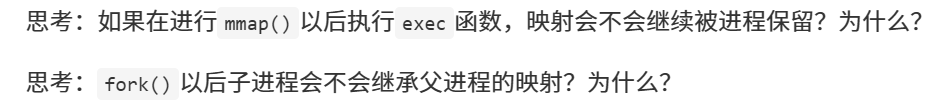

**A1**:

不会保留，新的进程映像会替换旧的，包括内存映射（除非指定了特殊标志）。`exec()` 系列函数会用一个新的程序完全替换当前进程的映像（代码段、数据段、堆栈等），但保留以下内容：`进程 ID（PID）、父进程 ID、文件描述符（除非设置了 FD_CLOEXEC 标志）、进程组 ID、会话 ID、真实用户/组 ID、信号处理设置`等

默认情况下，通过 `mmap()` 创建的内存映射不会在 `exec()` 后保留，原因包括：`映射关系被清除、虚拟内存空间被重置、新的程序加载到不同的地址空间`。
***
**A2**:

会继承。 子进程会复制父进程的整个地址空间，包括所有的内存映射。

`fork()` 创建子进程时，会执行`写时复制（Copy-On-Write, COW）`机制，这样确保了父子进程初始状态的一致性，支持了多进程共享数据的常见模式。

#### POSIX的共享内存
`shm_open()` 创建并打开一个新对象，或打开一个现有对象。这类似于 `open()`。该调用返回一个文件描述符，供下面列出的其他接口使用。
 
`ftruncate()` 设置共享内存对象的大小。（新创建的共享内存对象的长度为零。
 
`mmap()` 将共享内存对象映射到调用进程的虚拟地址空间。
 
`munmap()` 从调用进程的虚拟地址空间取消共享内存对象的映射。
 
`shm_unlink()` 删除共享内存对象名称。
 
`close()` 当不再需要时，关闭 `shm_open()` 分配的文件描述符。
 
`fstat()` 获取描述共享内存对象的 stat 结构。此调用返回的信息包括对象的大小 （`st_size`）、权限 （`st_mode`）、所有者 （`st_uid`） 和组 （`st_gid`）。
 
`fchown()` 更改共享内存对象的所有权。
 
`fchmod()` 更改共享内存对象的权限。

#### system V 的共享内存

##### shmget()
创建新分段或获取现有分段的 ID。此调用返回在其余 API 中使用的标识符。
 
```c
#include <sys/ipc.h>
#include <sys/shm.h>
 
int shmget(key_t key, size_t size, int shmflg);
```
 
##### shmat()
将现有的共享内存对象附加到调用进程的地址空间。
 
```c
#include <sys/types.h>
#include <sys/shm.h>
 
void *shmat(int shmid, const void *shmaddr, int shmflg);
```
 
##### shmdt()
将段与调用进程的地址空间分离。
 
```c
#include <sys/types.h>
#include <sys/shm.h>
 
int shmdt(const void *shmaddr);
```
 
##### shmctl()
对区段执行各种控制作，包括删除。
 
```c
#include <sys/ipc.h>
#include <sys/shm.h>
 
int shmctl(int shmid, int cmd, struct shmid_ds *buf);
```

###### 进行内存共享时，有时需要引入信号量来解决竞态条件问题

###### **共享内存同步的四种方法**：互斥锁、POSIX信号量（有名和无名）、SystemV信号灯以及信号

### 信号量
信号量是一个由内核维护的整数，其值被限定为大于或等于0，任何试图将信号量值降低到0之下的操作都会被阻塞。

#### 信号量常见操作
- 将信号量设置成一个绝对值；
- 在信号量当前值的基础上加上一个数量；
- 在信号量当前值的基础上减去一个数量；
- 等待信号量的值等于0；

内核会将所有试图将信号量值降低到0之下的操作阻塞

#### P/V操作

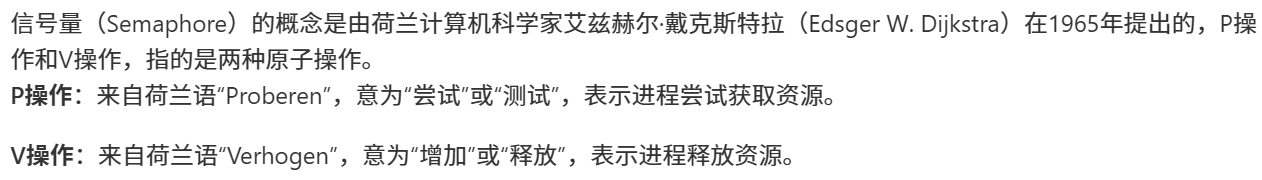